
# Assignment 1: Assessing Bicycle Lane Quality

## Team 1: Raina Allkoçi (1922785), Xinran Zhi (2565145), Rahma El Sayed (2551403)

**Objective:** Classify bicycle-lane conditions as smooth or bumpy using smartphone accelerometer, gyroscope, and gravity measurements.

## 1. Data Loading and Understanding

### 1.1 Imports and dataset location

Load the required libraries and locate the ZIP recordings. The checks below stop execution if the raw-data folder or recordings are missing.


In [ ]:
%pip install -q minisom==2.3.6

import sys
from importlib.metadata import version as package_version
from pathlib import Path
from zipfile import ZipFile

import matplotlib
import matplotlib.pyplot as plt
#Higher-resolution figures for readability in the executed notebook.
plt.rcParams["figure.dpi"] = 140
%config InlineBackend.figure_format = 'retina'
import numpy as np
import pandas as pd
import sklearn

from minisom import MiniSom
from sklearn.cluster import DBSCAN, KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    adjusted_rand_score,
    balanced_accuracy_score,
    ConfusionMatrixDisplay,
    f1_score,
    normalized_mutual_info_score,
    precision_score,
    recall_score,
    silhouette_score,
)
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import GridSearchCV, GroupKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

print("Python:", sys.version.split()[0])
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Matplotlib:", matplotlib.__version__)
print("scikit-learn:", sklearn.__version__)
print("MiniSom:", package_version("minisom"))

Note: you may need to restart the kernel to use updated packages.
Python: 3.12.14
NumPy: 2.5.3
Pandas: 3.0.6
Matplotlib: 3.11.2
scikit-learn: 1.9.1
MiniSom: 2.3.6


### 1.2 Load and combine the sensor recordings

For each ZIP, load the three requested sensors and verify that their timestamps align before combining them. Participant, road-condition, and recording identifiers are retained. Original ZIP files remain unchanged.

In [3]:
def load_recording(zip_path):

    """Read one ZIP recording and align its three sensor files by timestamp."""
    
    with ZipFile(zip_path, "r") as archive:
        with archive.open("Accelerometer.csv") as file:
            acc = pd.read_csv(file)
        with archive.open("Gyroscope.csv") as file:
            gyro = pd.read_csv(file)
        with archive.open("Gravity.csv") as file:
            gravity = pd.read_csv(file)

    if not (acc["time"].equals(gyro["time"])
            and acc["time"].equals(gravity["time"])):
        raise ValueError(f"Sensor timestamps do not match: {zip_path}")

    return pd.DataFrame({
        "time": acc["time"],
        "seconds_elapsed": acc["seconds_elapsed"],
        "acc_x": acc["x"], "acc_y": acc["y"], "acc_z": acc["z"],
        "gyro_x": gyro["x"], "gyro_y": gyro["y"], "gyro_z": gyro["z"],
        "gravity_x": gravity["x"], "gravity_y": gravity["y"],
        "gravity_z": gravity["z"]
    })

In [4]:
working_dir = Path.cwd()

project_folder = (working_dir
    if (working_dir / "raw data file").is_dir()
    else working_dir.parent)

data_folder = project_folder / "raw data file"

if not data_folder.is_dir():
    raise FileNotFoundError(f"Raw data folder not found: {data_folder}")

zip_files = sorted(data_folder.rglob("*.zip"))

if not zip_files:
    raise FileNotFoundError(f"No ZIP recordings found in {data_folder}")

print(
    "ZIP recordings found:",
    len(zip_files)
)

ZIP recordings found: 30


In [5]:
all_recordings = []
for zip_path in zip_files:
    participant = zip_path.parent.parent.name
    road_condition = zip_path.parent.name.lower()

    recording = load_recording(zip_path)
    recording["participant"] = participant
    recording["road_condition"] = road_condition
    #Unique recording ID relative to the raw-data folder.
    recording["recording_id"] = zip_path.relative_to(data_folder).as_posix()
    all_recordings.append(recording)

combined_df = pd.concat(all_recordings, ignore_index=True)
print("Combined dataset shape:", combined_df.shape)
print("Number of recordings:", combined_df["recording_id"].nunique())
print("Number of participants:", combined_df["participant"].nunique())
display(combined_df.head())

Combined dataset shape: (420506, 14)
Number of recordings: 30
Number of participants: 3


,time,seconds_elapsed,acc_x,acc_y,acc_z,gyro_x,gyro_y,gyro_z,gravity_x,gravity_y,gravity_z,participant,road_condition,recording_id
0,1789734532680360400,0.053360,0.525098,0.198844,-0.317852,0.576124,-0.386222,-0.125969,-0.723667,4.737252,8.556000,participant_1,bumpy,participant_1/bumpy/p1_bumpy_1.zip
1,1789734532690368800,0.063369,0.499797,0.149029,-0.292189,0.611401,-0.374717,-0.186475,-0.698366,4.787067,8.530338,participant_1,bumpy,participant_1/bumpy/p1_bumpy_1.zip
2,1789734532700376800,0.073377,0.565957,0.457386,0.393400,0.628788,-0.322669,-0.266257,-0.679233,4.838439,8.502855,participant_1,bumpy,participant_1/bumpy/p1_bumpy_1.zip
3,1789734532710384600,0.083385,0.593435,0.282436,0.727975,0.666647,-0.203669,-0.363661,-0.671845,4.891135,8.473240,participant_1,bumpy,participant_1/bumpy/p1_bumpy_1.zip
4,1789734532720392700,0.093393,0.555283,-0.118405,0.713513,0.723867,-0.047215,-0.479859,-0.681876,4.947210,8.439819,participant_1,bumpy,participant_1/bumpy/p1_bumpy_1.zip


### 1.3 Dataset overview and quality checks

Summarize recording counts and durations. The road-condition labels apply to **the whole recording**, which means that recordings labeled 'bumpy' can still contain smooth sections.

In [6]:
recording_counts = (
    combined_df.groupby(["participant", "road_condition"])["recording_id"]
    .nunique().unstack(fill_value=0)
)
recording_durations = (
    combined_df.groupby(["participant", "road_condition", "recording_id"])
    ["seconds_elapsed"].agg(lambda values: values.max() - values.min())
    .reset_index(name="duration_seconds")
)
duration_summary = (
    recording_durations.groupby("road_condition")["duration_seconds"]
    .agg(["count", "sum", "mean", "min", "max"])
)

print("Recording counts by participant and condition:")
display(recording_counts)
print("Recording durations (seconds) by condition:")
display(duration_summary)

Recording counts by participant and condition:


road_condition,bumpy,smooth
participant,,
participant_1,7,3
participant_2,7,3
participant_3,6,4


Recording durations (seconds) by condition:


,count,sum,mean,min,max
road_condition,,,,,
bumpy,20,2720.861194,136.043060,34.333133,265.051933
smooth,10,1486.669629,148.666963,40.704864,292.451381


## 2. Exploratory Data Analysis

Compare acceleration magnitude from smooth and bumpy recordings, and visualize possible phone-handling artifacts at their boundaries. Magnitude summarizes movement, but peaks alone do not establish the road condition.

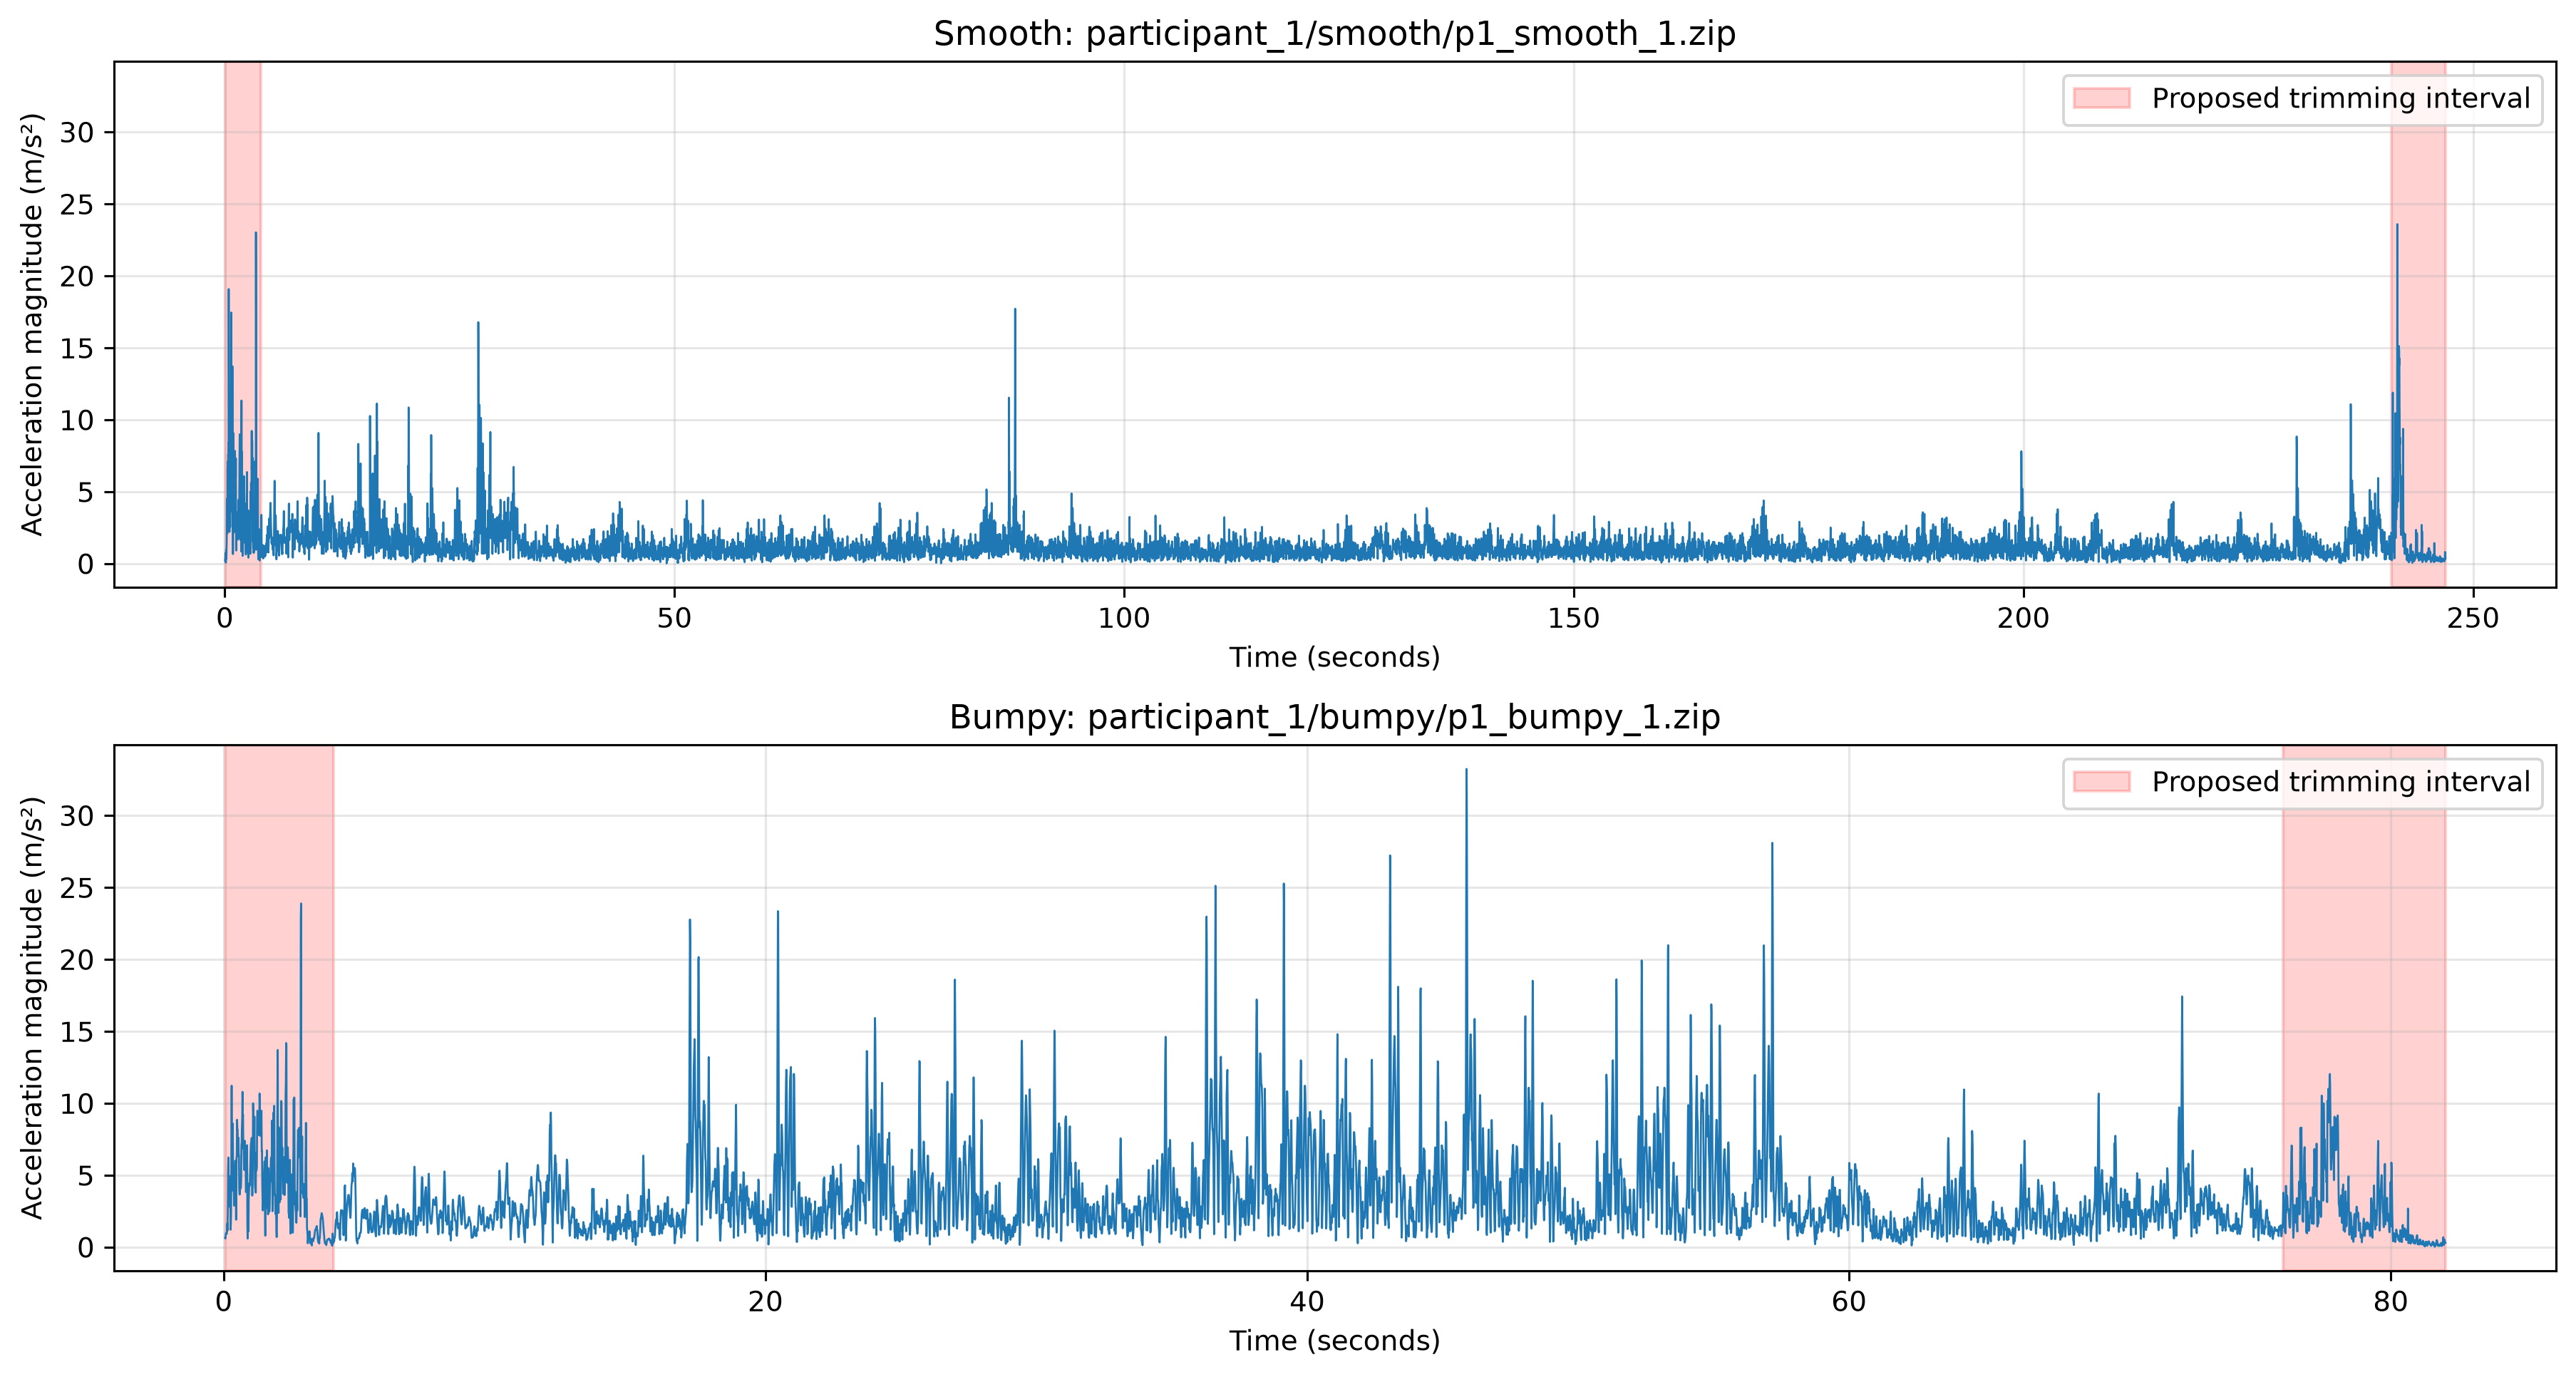

In [7]:
#keep original x, y, z axes
#magnitude combines their overall acceleration.
combined_df["acc_magnitude"] = np.sqrt(
    combined_df["acc_x"]**2 + combined_df["acc_y"]**2 + combined_df["acc_z"]**2
)

participant = "participant_1"
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharey=True)

for ax, condition in zip(axes, ["smooth", "bumpy"]):
    subset = combined_df.loc[
        (combined_df["participant"] == participant)
        & (combined_df["road_condition"] == condition)
    ]
    if subset.empty:
        raise ValueError(f"No {condition} recording found for {participant}")
    recording_id = subset["recording_id"].iloc[0]
    recording = subset.loc[subset["recording_id"] == recording_id]

    ax.plot(recording["seconds_elapsed"], recording["acc_magnitude"], linewidth=0.7)
    start, end = recording["seconds_elapsed"].min(), recording["seconds_elapsed"].max()
    ax.axvspan(start, start + 4, color="red", alpha=0.18, label="Proposed trimming interval")
    ax.axvspan(end - 6, end, color="red", alpha=0.18)
    ax.set(title=f"{condition.capitalize()}: {recording_id}",
           ylabel="Acceleration magnitude (m/s²)", xlabel="Time (seconds)")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper right")
plt.tight_layout()
plt.show()


### 2.1 Recording duration by participant and condition
 Recording lengths vary across participants and conditions, meaning that some recordings contribute more sensor measurements than others. Model evaluation is therefore performed at participant level rather than by randomly splitting individual measurements.

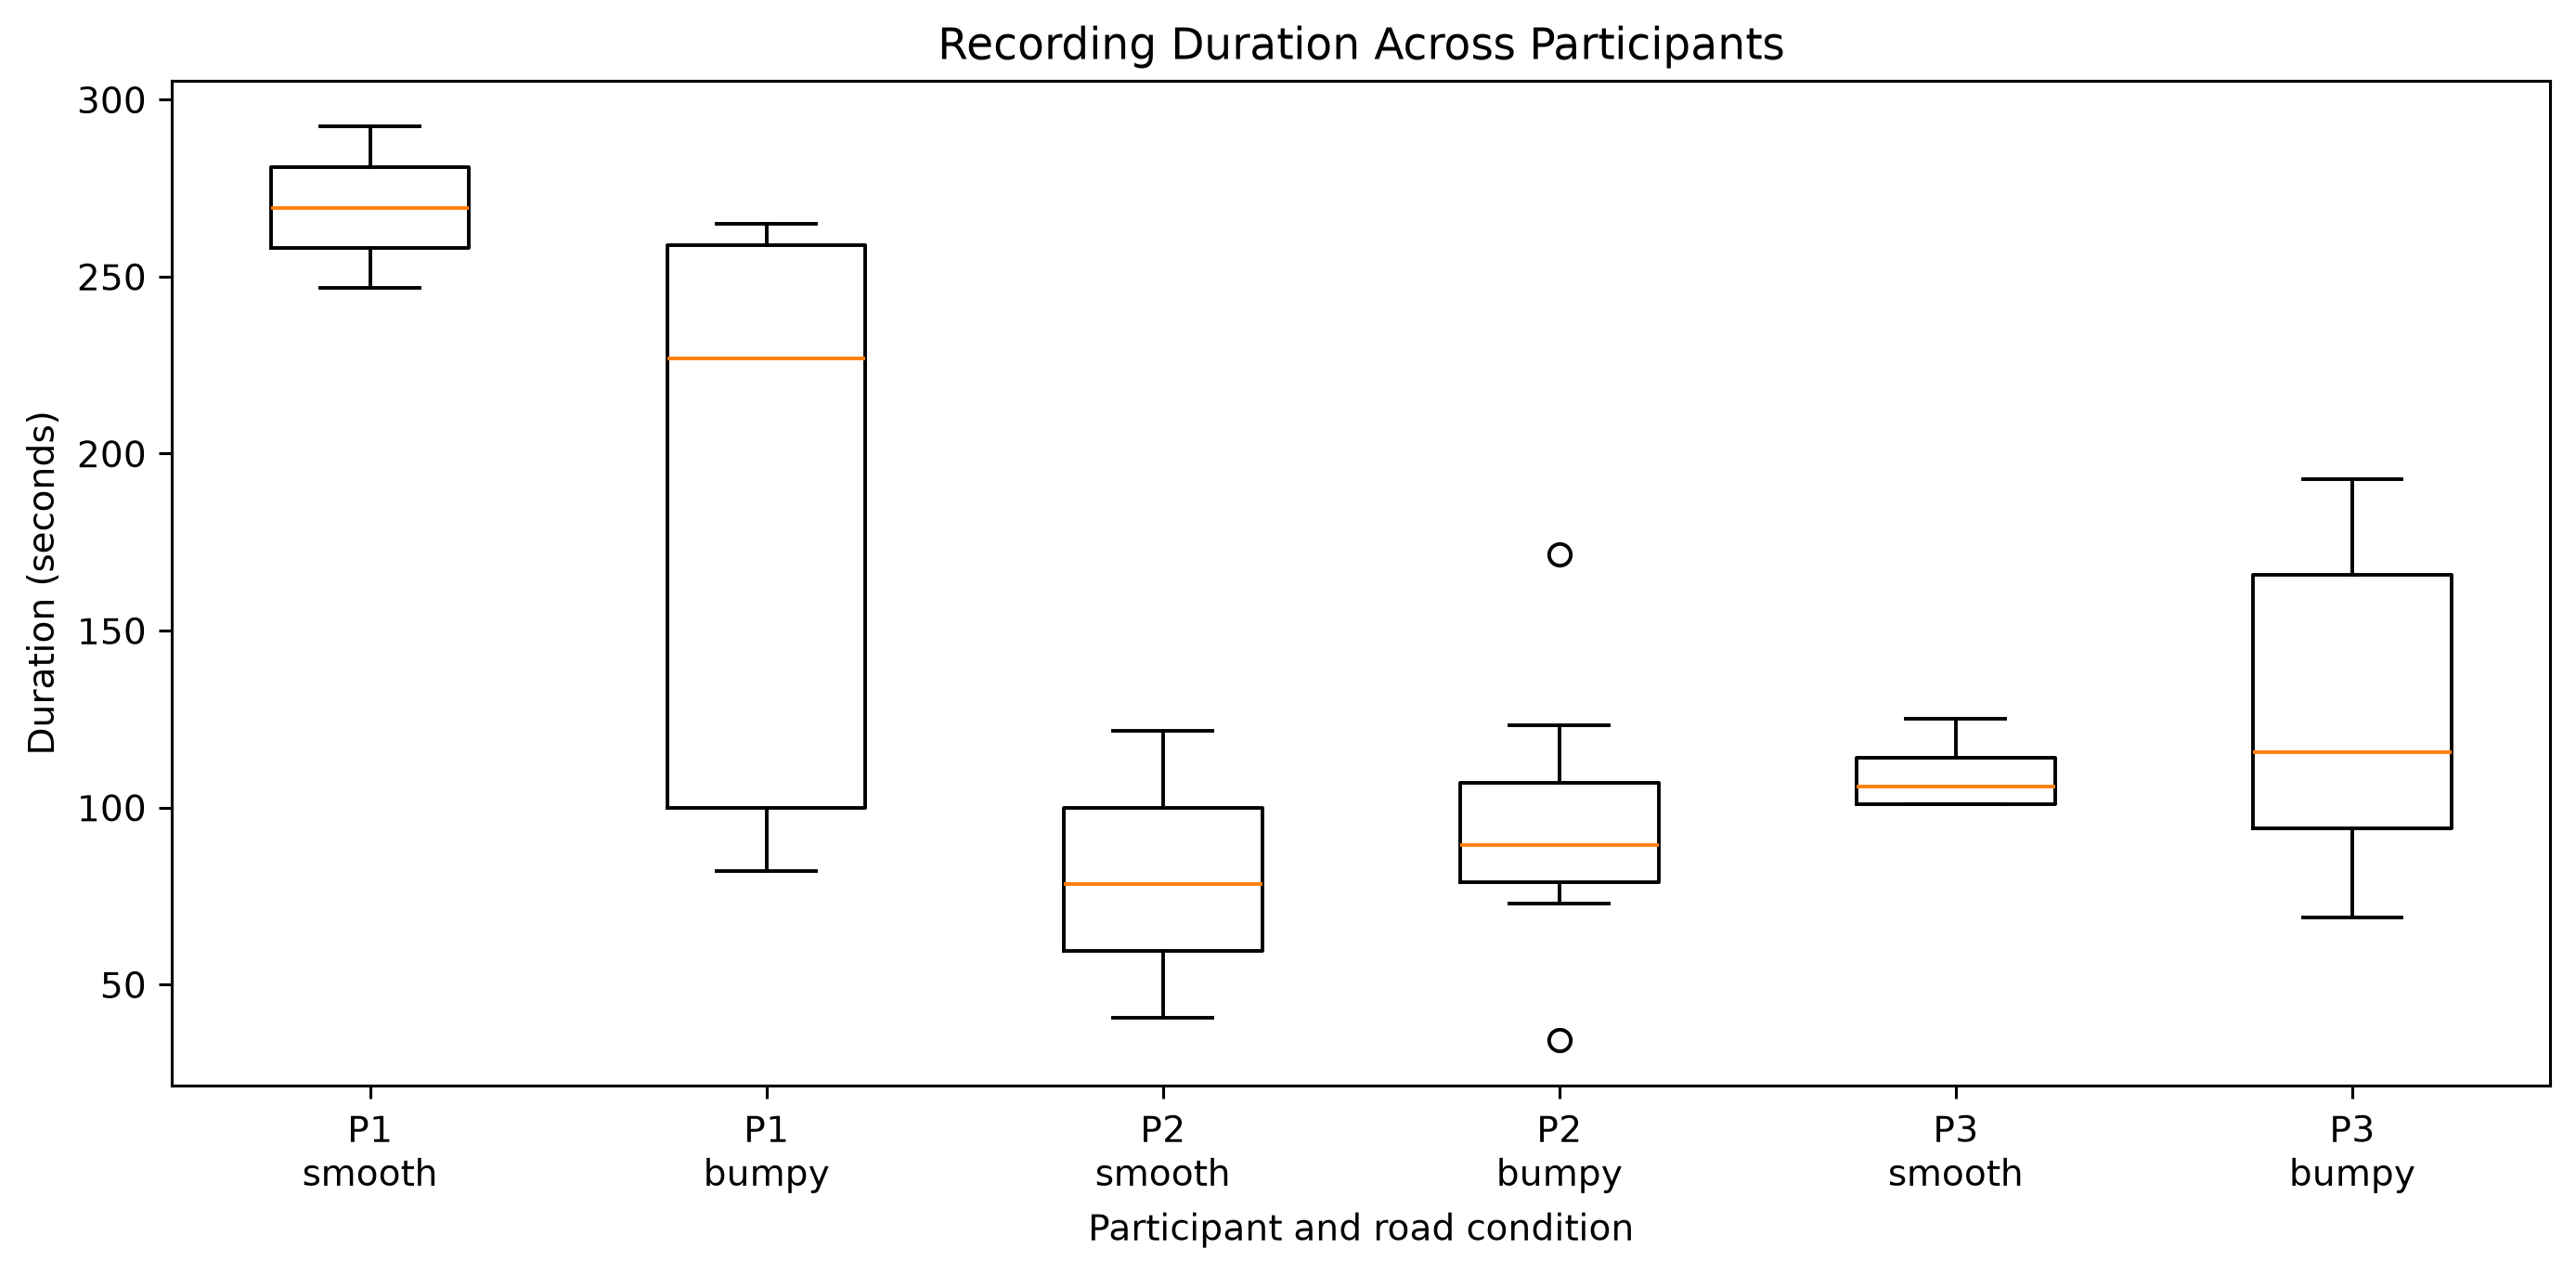

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))

labels = []
duration_data = []

for participant in sorted(recording_durations["participant"].unique()):
    for condition in ["smooth", "bumpy"]:
        values = recording_durations.loc[
            (recording_durations["participant"] == participant)
            & (recording_durations["road_condition"] == condition),
            "duration_seconds"
        ]

        labels.append(
            f"{participant.replace('participant_', 'P')}\n{condition}"
        )
        duration_data.append(values)

ax.boxplot(
    duration_data,
    tick_labels=labels
)

ax.set_title("Recording Duration Across Participants")
ax.set_ylabel("Duration (seconds)")
ax.set_xlabel("Participant and road condition")

plt.tight_layout()
plt.show()

### 2.2 Recording-level acceleration variability

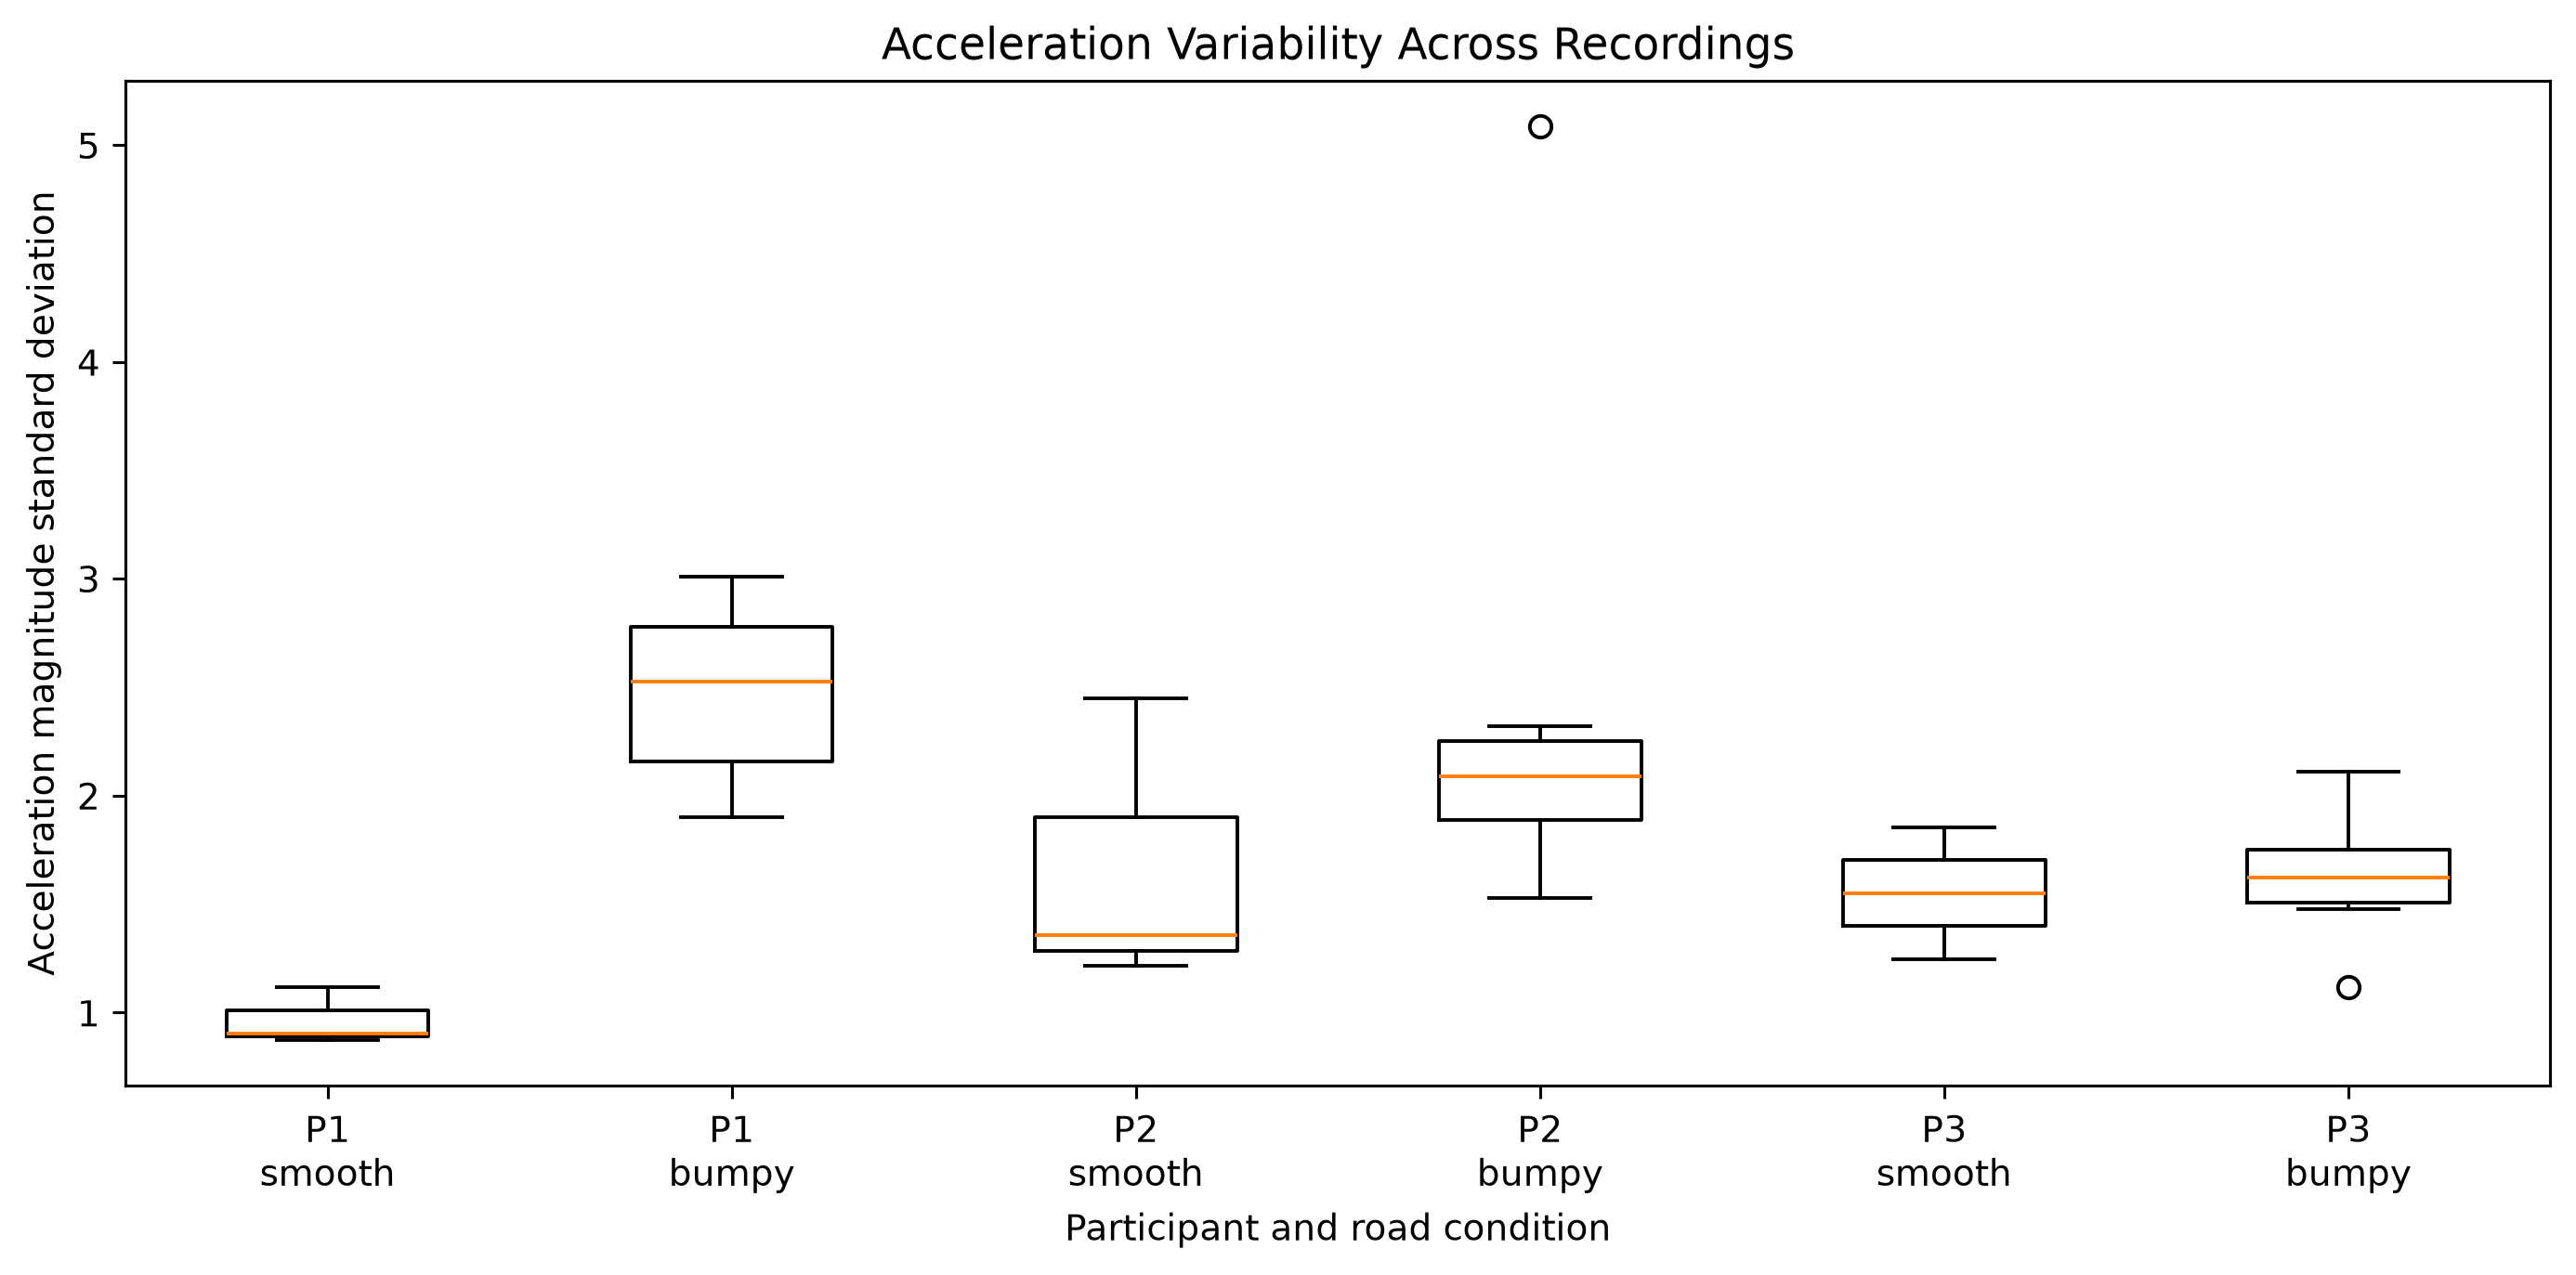

In [9]:
eda_df = combined_df.copy()

eda_df["acc_magnitude"] = np.sqrt(
    eda_df["acc_x"]**2
    + eda_df["acc_y"]**2
    + eda_df["acc_z"]**2
)

recording_variability = (
    eda_df
    .groupby(
        [
            "recording_id",
            "participant",
            "road_condition"
        ]
    )
    ["acc_magnitude"]
    .std()
    .reset_index(
        name="acc_magnitude_std"
    )
)

fig, ax = plt.subplots(figsize=(10, 5))

labels = []
variability_data = []

for participant in sorted(
    recording_variability["participant"].unique()
):
    for condition in ["smooth", "bumpy"]:

        values = recording_variability.loc[
            (
                recording_variability["participant"]
                == participant
            )
            &
            (
                recording_variability["road_condition"]
                == condition
            ),
            "acc_magnitude_std"
        ]

        labels.append(
            f"{participant.replace('participant_', 'P')}\n{condition}"
        )

        variability_data.append(values)

ax.boxplot(
    variability_data,
    tick_labels=labels
)

ax.set_title("Acceleration Variability Across Recordings")

ax.set_ylabel( "Acceleration magnitude standard deviation")

ax.set_xlabel("Participant and road condition")

plt.tight_layout()
plt.show()


## 3. Data Preprocessing

### 3.1 Remove Phone-Handling Periods

The first 4 seconds and last 6 seconds of each recording are excluded to reduce artifacts caused by inserting and removing the smartphone from the back pocket.

The trimming procedure is applied independently to each recording, preserving the original raw data.

In [10]:
trim_start = 4  # seconds
trim_end = 6    # seconds
trimmed_recordings = []

for recording_id, recording in combined_df.groupby("recording_id", sort=False):
    start = recording["seconds_elapsed"].min()
    end = recording["seconds_elapsed"].max()
    if start + trim_start >= end - trim_end: #if it's too short
        raise ValueError(f"Recording too short to trim: {recording_id}")
    trimmed_recordings.append(recording.loc[
        (recording["seconds_elapsed"] >= start + trim_start)
        & (recording["seconds_elapsed"] <= end - trim_end)
    ].copy())

trimmed_df = pd.concat(trimmed_recordings, ignore_index=True)
print(f"Measurements: {len(combined_df):,} before -> {len(trimmed_df):,} after trimming")
print("Recordings retained:", trimmed_df["recording_id"].nunique())
assert trimmed_df["recording_id"].nunique() == combined_df["recording_id"].nunique()


Measurements: 420,506 before -> 390,501 after trimming
Recordings retained: 30



## 4. Feature Engineering and Extraction

### 4.1 Divide the retained recordings into windows

Divide each trimmed recording into non-overlapping 2-second intervals (about 200 samples at 100 Hz). All retained cycling data are considered, not just the interval used in the example plot below. Window IDs restart for each recording.

In [11]:
window_duration = 2  # seconds
windowed_recordings = []
for recording_id, recording in trimmed_df.groupby("recording_id", sort=False):
    recording = recording.sort_values("seconds_elapsed").copy()
    first_time = recording["seconds_elapsed"].iloc[0]
    recording["window_id"] = (
        (recording["seconds_elapsed"] - first_time) // window_duration
    ).astype(int)
    windowed_recordings.append(recording)

windowed_df = pd.concat(windowed_recordings, ignore_index=True)
print("Windows before incomplete-window filtering:",
      windowed_df.groupby(["recording_id", "window_id"]).ngroups)


Windows before incomplete-window filtering: 1969


### 4.2 Visualize the window boundaries

The following 20-second view is **illustrative only**. Its shaded windows use the same IDs and boundaries as the full-recording window assignment above. Change `example_id` to examine another recording.

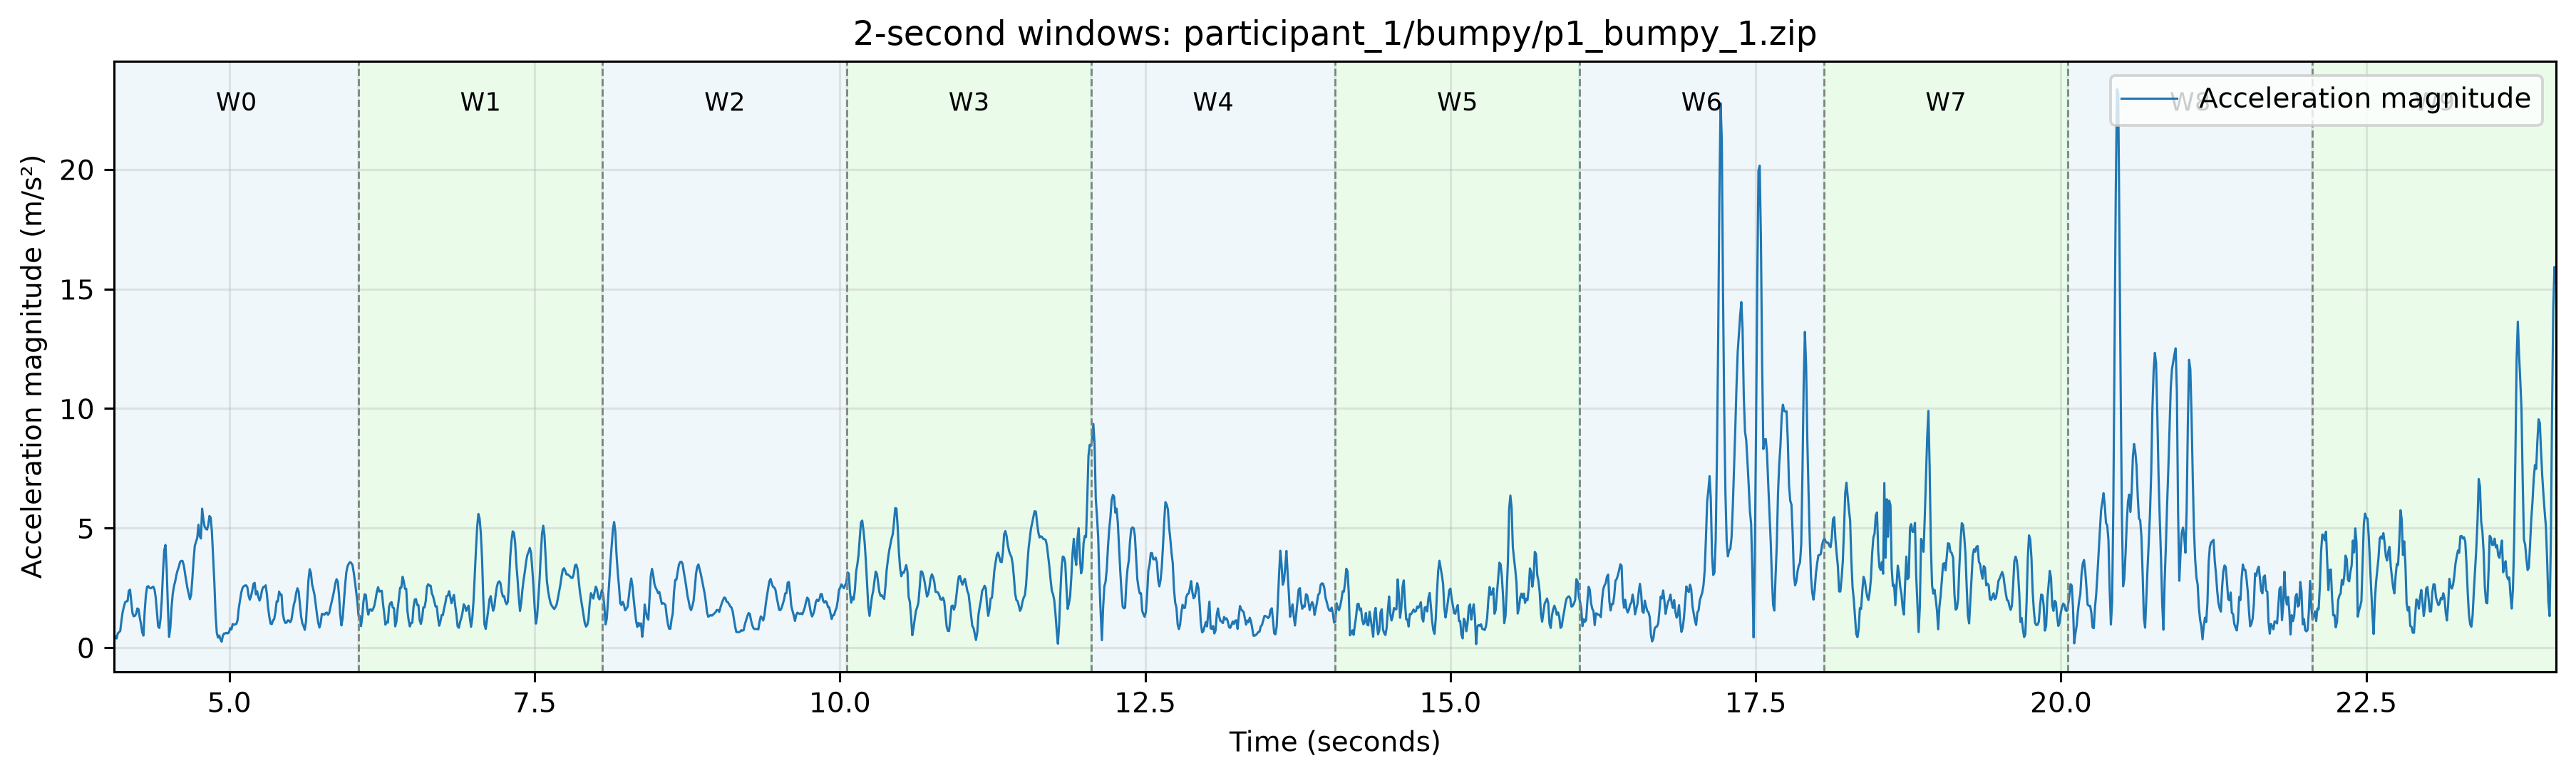

In [12]:
example_id = trimmed_df["recording_id"].iloc[0]
example = windowed_df.loc[windowed_df["recording_id"] == example_id].copy()
if example.empty: #if typed wrong 
    raise ValueError(f"Recording not found: {example_id}")

segment_start = example["seconds_elapsed"].min()  #starts at W0
segment_end = min(segment_start + 20, example["seconds_elapsed"].max())
segment = example.loc[example["seconds_elapsed"].between(segment_start, segment_end)]

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(segment["seconds_elapsed"], segment["acc_magnitude"],
        linewidth=0.8, label="Acceleration magnitude")

for window_id, window in segment.groupby("window_id", sort=True):
    #actual bounds are anchored to the first sample of the trimmed recording.
    start = example["seconds_elapsed"].min() + window_id * window_duration
    end = start + window_duration
    left, right = max(start, segment_start), min(end, segment_end)
    if left >= right:
        continue
    ax.axvspan(left, right, alpha=0.18,
               color="lightblue" if window_id % 2 == 0 else "lightgreen")
    ax.axvline(left, linestyle="--", linewidth=0.7, color="gray")
    #label only complete visible windows to avoid edge overlaps.
    if start >= segment_start and end <= segment_end:
        ax.text((start + end) / 2, 0.93, f"W{window_id}",
                ha="center", va="center", fontsize=9,
                transform=ax.get_xaxis_transform())

ax.set(xlim=(segment_start, segment_end),
       title=f"2-second windows: {example_id}",
       xlabel="Time (seconds)", ylabel="Acceleration magnitude (m/s²)")
ax.grid(True, alpha=0.3)
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()


### 4.3 Check window sizes

At 100 Hz, each 2-second window should contain approximately 200 measurements. Windows containing fewer than 180 measurements (90% of the expected samples) are excluded to ensure that features are extracted from intervals of comparable duration.

In [13]:
window_sizes = (
    windowed_df.groupby(["recording_id", "window_id"])
    .size().reset_index(name="n_samples")
)
print("Samples per window (before filtering):")
display(window_sizes["n_samples"].describe())

min_samples = 180
valid_windows = window_sizes.loc[
    window_sizes["n_samples"] >= min_samples, ["recording_id", "window_id"]
]
windowed_df = windowed_df.merge(
    valid_windows, on=["recording_id", "window_id"], how="inner"
)
print("Windows retained:", len(valid_windows))
print("Recordings retained:", windowed_df["recording_id"].nunique())


Samples per window (before filtering):


count    1969.000000
mean      198.324530
std        13.650613
min        24.000000
25%       200.000000
50%       200.000000
75%       200.000000
max       201.000000
Name: n_samples, dtype: float64

Windows retained: 1941
Recordings retained: 30


### 4.4 Feature Extraction

Statistical features are extracted from each retained 2-second window using accelerometer, gyroscope, and gravity measurements. Mean and standard deviation describe the average movement and variability, while maximum magnitude and root mean square (RMS) capture strong movements and overall signal intensity.


**Note:** The `road_condition` value is inherited from the **whole recording**, not independently verified for each window.

In [14]:
#acceleration and gyroscope magnitudes
windowed_df["acc_magnitude"] = np.sqrt(
    windowed_df["acc_x"]**2
    + windowed_df["acc_y"]**2
    + windowed_df["acc_z"]**2
)

windowed_df["gyro_magnitude"] = np.sqrt(
    windowed_df["gyro_x"]**2
    + windowed_df["gyro_y"]**2
    + windowed_df["gyro_z"]**2
)

#sensor signals used for feature extraction
sensor_columns = [
    "acc_x", "acc_y", "acc_z", "acc_magnitude",
    "gyro_x", "gyro_y", "gyro_z", "gyro_magnitude",
    "gravity_x", "gravity_y", "gravity_z"
]

#mean and standard deviation for each window
features_df = (
    windowed_df.groupby(
        ["recording_id", "window_id"]
    )[sensor_columns]
    .agg(["mean", "std"])
)

features_df.columns = [
    f"{sensor}_{statistic}"
    for sensor, statistic in features_df.columns
]

features_df = features_df.reset_index()

#additional magnitude features
magnitude_features = (
    windowed_df.groupby(
        ["recording_id", "window_id"]
    )
    .agg(
        acc_magnitude_max=("acc_magnitude", "max"),
        acc_magnitude_rms=(
            "acc_magnitude",
            lambda x: np.sqrt(np.mean(x**2))
        ),
        gyro_magnitude_max=("gyro_magnitude", "max"),
        gyro_magnitude_rms=(
            "gyro_magnitude",
            lambda x: np.sqrt(np.mean(x**2))
        )
    )
    .reset_index()
)

#save recording information and road-condition labels
window_info = (
    windowed_df.groupby(
        ["recording_id", "window_id"]
    )
    .agg(
        participant=("participant", "first"),
        road_condition=("road_condition", "first"),
        window_start=("seconds_elapsed", "min"),
        window_end=("seconds_elapsed", "max")
    )
    .reset_index()
)

#combine all features and recording information
features_df = (
    features_df
    .merge(
        magnitude_features,
        on=["recording_id", "window_id"]
    )
    .merge(
        window_info,
        on=["recording_id", "window_id"]
    )
)

In [15]:

#verify the feature dataset
print("Total windows:", len(features_df))
print("Numerical features:", 26)
print("Recordings:", features_df["recording_id"].nunique())
print("Missing values:", features_df.isnull().sum().sum())


window_summary = (
    features_df.groupby(["participant", "road_condition"])
    .size()
    .unstack(fill_value=0)
)

print("\nWindows per participant and road condition:")
display(window_summary)


#select representative features from all three sensors
display_columns = [
    "participant",
    "road_condition",
    "window_id",
    "acc_magnitude_mean",
    "acc_magnitude_std",
    "gyro_magnitude_std",
    "gravity_z_mean"
]

#display one example window per participant and road condition
feature_preview = (
    features_df.groupby(
        ["participant", "road_condition"],
        sort=True
    )
    .head(1)[display_columns]
    .reset_index(drop=True)
)

print("Example feature vectors:")
display(feature_preview.round(3))

Total windows: 1941
Numerical features: 26
Recordings: 30
Missing values: 0

Windows per participant and road condition:


road_condition,bumpy,smooth
participant,,
participant_1,608,388
participant_2,295,104
participant_3,349,197


Example feature vectors:


,participant,road_condition,window_id,acc_magnitude_mean,acc_magnitude_std,gyro_magnitude_std,gravity_z_mean
0,participant_1,bumpy,0,2.129,1.195,0.595,-2.011
1,participant_1,smooth,0,1.698,1.059,0.279,-3.462
2,participant_2,bumpy,0,6.168,3.557,0.152,7.504
3,participant_2,smooth,0,1.606,1.114,0.733,1.658
4,participant_3,bumpy,0,1.789,0.700,0.264,0.695
5,participant_3,smooth,0,1.617,0.870,0.524,0.242


### 4.5 Feature Distributions Across Participants

The distributions of acceleration and gyroscope variability are compared across participants and recording labels. This helps identify participant-specific sensor differences that may influence generalization to unseen cyclists.

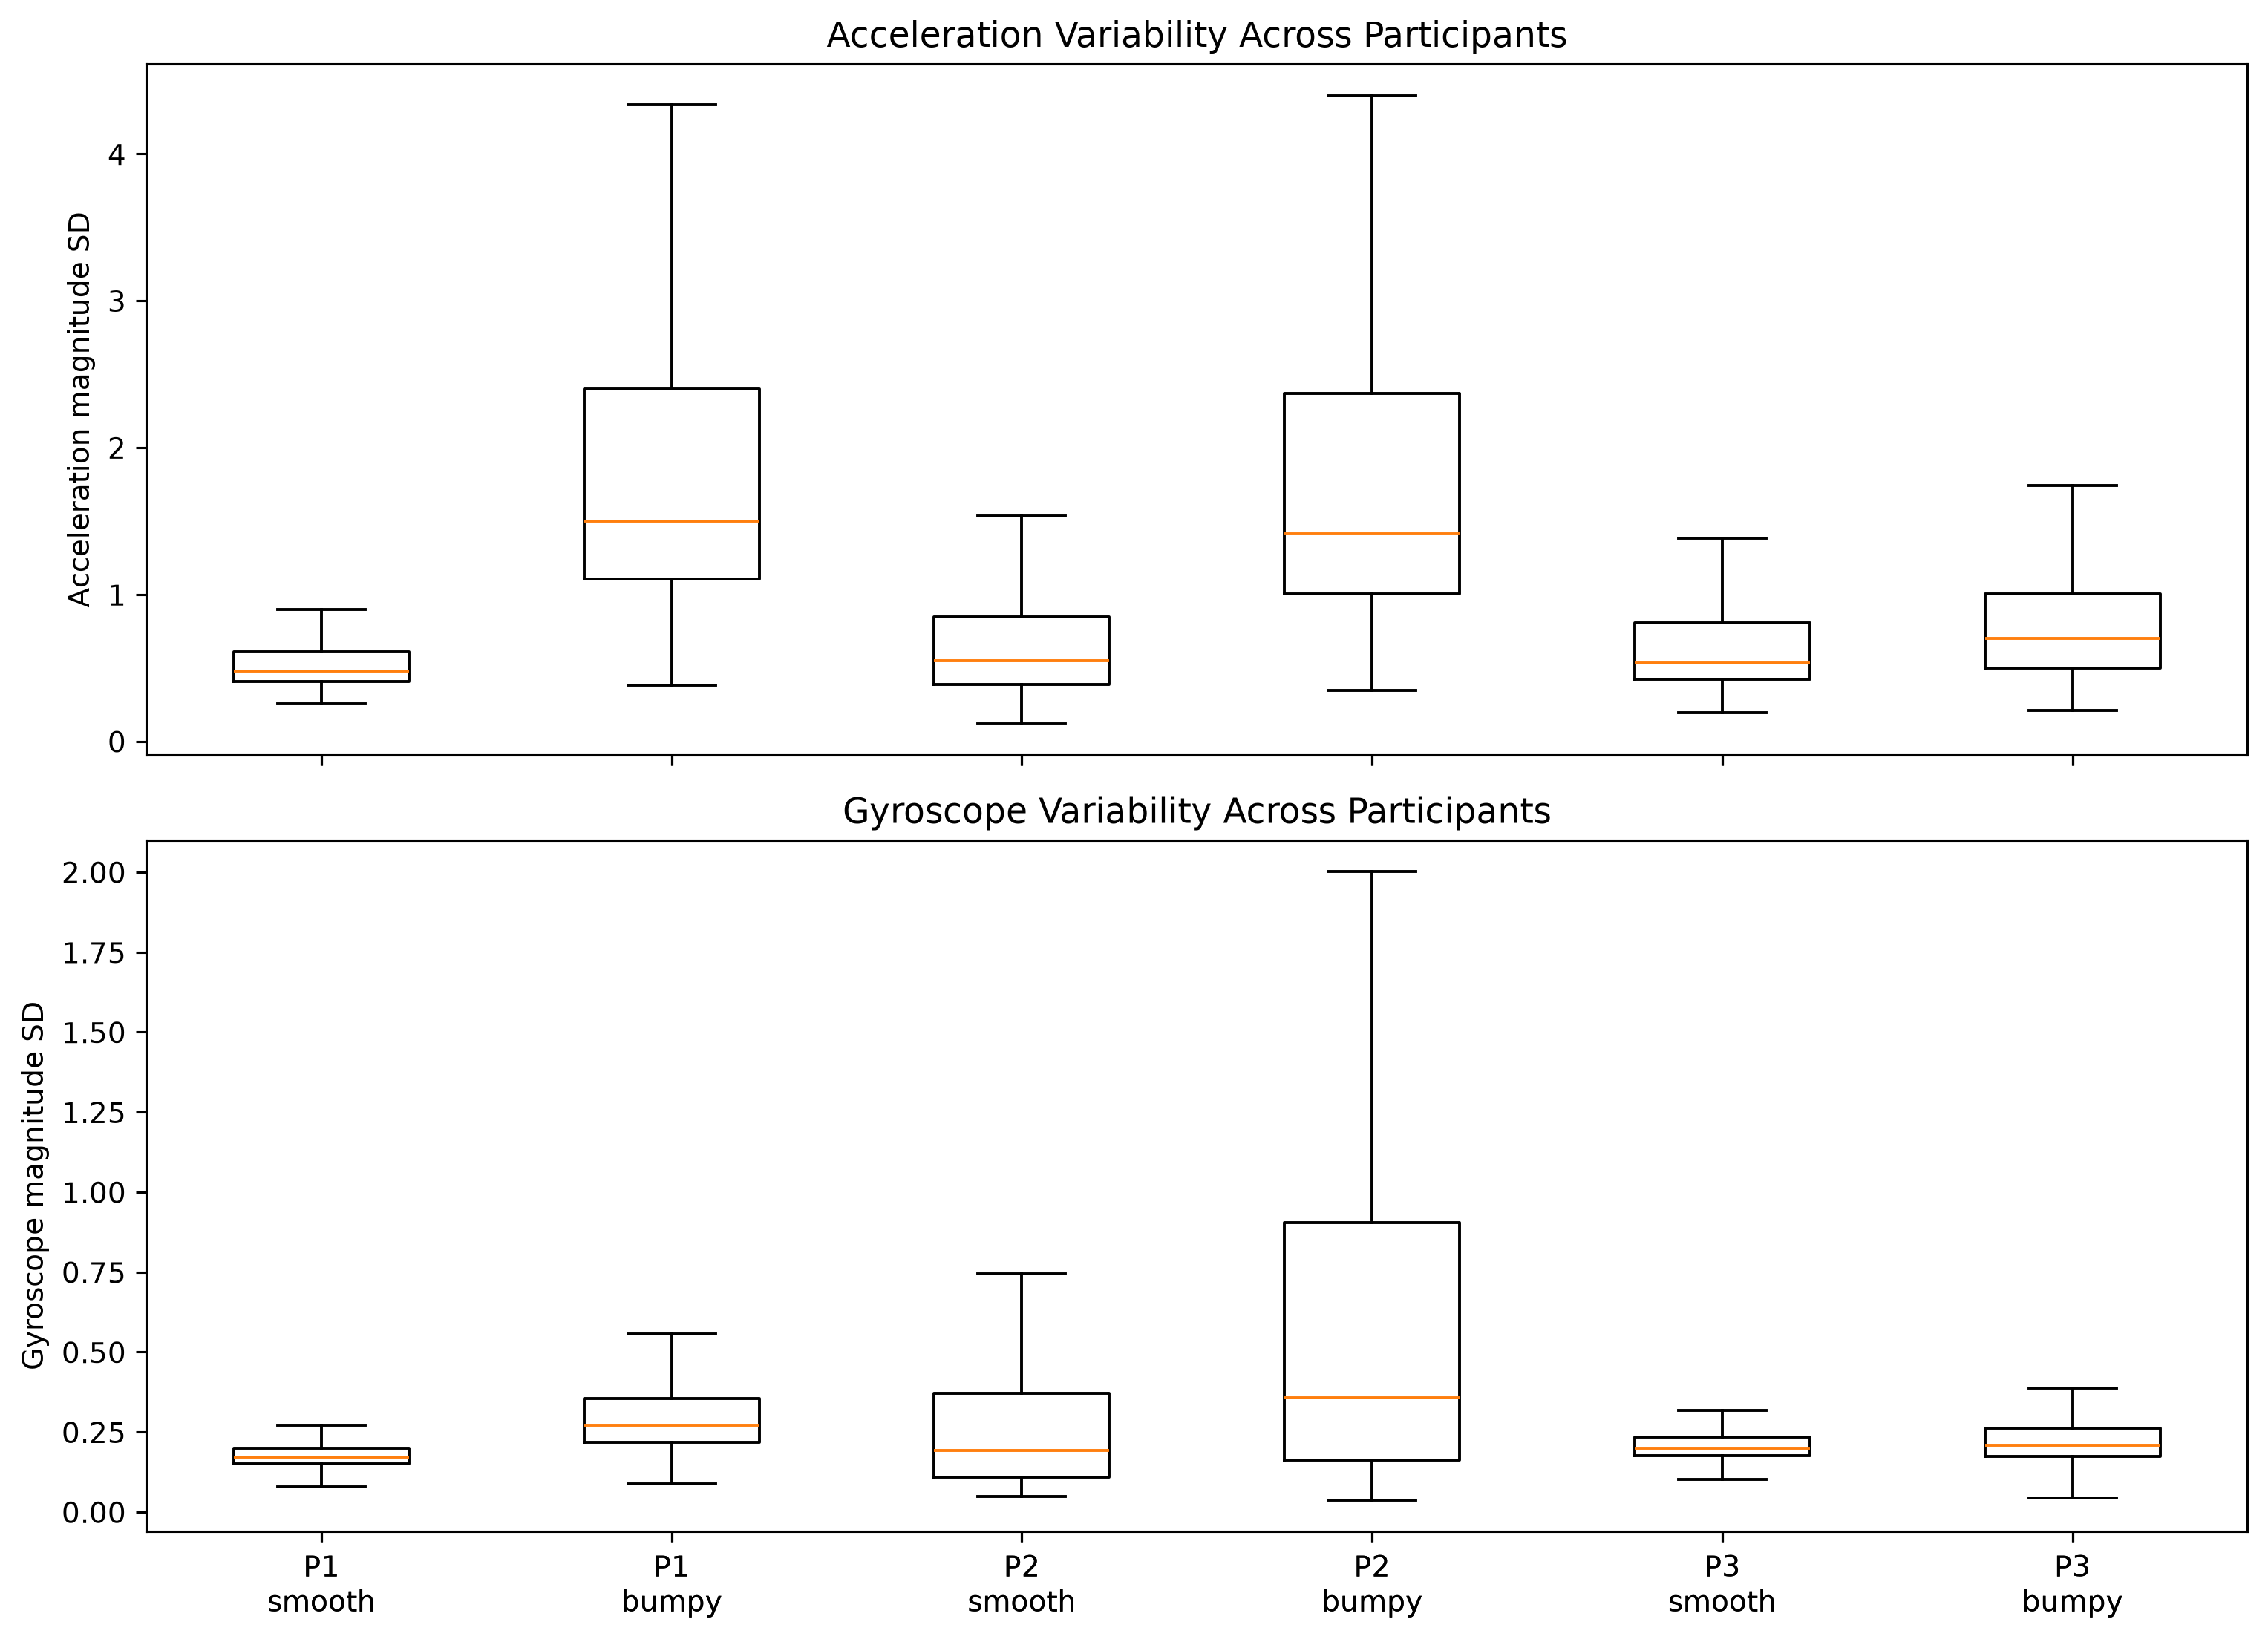

In [16]:
group_labels = []
acc_data = []
gyro_data = []

for participant in sorted(features_df["participant"].unique()):
    for condition in ["smooth", "bumpy"]:

        subset = features_df.loc[
            (features_df["participant"] == participant)
            & (features_df["road_condition"] == condition)
        ]

        group_labels.append(
            f"{participant.replace('participant_', 'P')}\n{condition}"
        )

        acc_data.append(
            subset["acc_magnitude_std"]
        )

        gyro_data.append(
            subset["gyro_magnitude_std"]
        )

fig, axes = plt.subplots(
    2, 1,
    figsize=(11, 8),
    sharex=True
)

axes[0].boxplot(
    acc_data,
    tick_labels=group_labels,
    showfliers=False
)

axes[0].set_ylabel("Acceleration magnitude SD")
axes[0].set_title("Acceleration Variability Across Participants")

axes[1].boxplot(
    gyro_data,
    tick_labels=group_labels,
    showfliers=False
)

axes[1].set_ylabel("Gyroscope magnitude SD")
axes[1].set_title("Gyroscope Variability Across Participants")

plt.tight_layout()
plt.show()

## 5: Preparing the Data for Machine Learning.

### 5.1 Dataset for Modeling
Each row represents one retained 2-second window. Sensor-derived features form the feature matrix X. Road-condition labels form the target y, encoded as smooth = 0 and bumpy = 1.
Participant and recording identifiers, window IDs, and timestamps are excluded from the predictors and retained as metadata.



In [17]:
# Separate metadata from sensor features.
metadata_columns = [
    "recording_id",
    "window_id",
    "participant",
    "road_condition",
    "window_start",
    "window_end"
]

feature_columns = [
    column for column in features_df.columns
    if column not in metadata_columns
]

X = features_df[feature_columns].copy()

label_mapping = {"smooth": 0, "bumpy": 1}
y = features_df["road_condition"].map(label_mapping)

# Check the modeling dataset.
assert y.notna().all(), "Unexpected or missing labels."
assert X.select_dtypes(include="number").shape[1] == X.shape[1]
assert np.isfinite(X.to_numpy()).all(), "Features contain NaN or infinity."
assert not features_df.duplicated(
    ["recording_id", "window_id"]
).any(), "Duplicate windows found."

y = y.astype(int)

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("Label mapping:", label_mapping)

display(
    features_df["road_condition"]
    .value_counts()
    .rename_axis("road_condition")
    .to_frame("n_windows")
)

Feature matrix shape: (1941, 26)
Target shape: (1941,)
Label mapping: {'smooth': 0, 'bumpy': 1}


,n_windows
road_condition,
bumpy,1252
smooth,689


### 5.2 Participant-wise LOSO Splits

Leave-one-participant-out (LOSO) evaluation creates three outer splits. In each split, one participant is held out for testing and the other two are used for model development. Participant and recording overlap are checked to prevent related windows from appearing on both sides of a split.



In [18]:
# Section 5.2: Create and check the outer LOSO splits.
participants = sorted(features_df["participant"].unique())

# Start from empty lists every time this cell runs.
loso_splits = []
split_rows = []

for fold, test_participant in enumerate(participants, start=1):
    test_mask = features_df["participant"].eq(test_participant)
    train_mask = ~test_mask

    train_metadata = features_df.loc[train_mask, metadata_columns]
    test_metadata = features_df.loc[test_mask, metadata_columns]

    # Participants and recordings must not overlap.
    assert set(train_metadata["participant"]).isdisjoint(
        set(test_metadata["participant"])
    )
    assert set(train_metadata["recording_id"]).isdisjoint(
        set(test_metadata["recording_id"])
    )

    # Both classes must be present.
    assert set(y.loc[train_mask].unique()) == {0, 1}
    assert set(y.loc[test_mask].unique()) == {0, 1}

    # Save each checked split for Section 6.
    loso_splits.append({
        "held_out_participant": test_participant,
        "train_mask": train_mask.copy(),
        "test_mask": test_mask.copy()
    })

    split_rows.append({
        "fold": fold,
        "training_participants": ", ".join(
            sorted(train_metadata["participant"].unique())
        ),
        "test_participant": test_participant,
        "train_windows": int(train_mask.sum()),
        "test_windows": int(test_mask.sum()),
        "train_smooth": int((y.loc[train_mask] == 0).sum()),
        "train_bumpy": int((y.loc[train_mask] == 1).sum()),
        "test_smooth": int((y.loc[test_mask] == 0).sum()),
        "test_bumpy": int((y.loc[test_mask] == 1).sum())
    })

split_summary = pd.DataFrame(split_rows)

assert len(loso_splits) == len(participants)

print("Number of LOSO splits:", len(loso_splits))
display(split_summary)

Number of LOSO splits: 3


,fold,training_participants,test_participant,train_windows,test_windows,train_smooth,train_bumpy,test_smooth,test_bumpy
0,1,"participant_2, participant_3",participant_1,945,996,301,644,388,608
1,2,"participant_1, participant_3",participant_2,1542,399,585,957,104,295
2,3,"participant_1, participant_2",participant_3,1395,546,492,903,197,349


### 5.3 Feature Selection — Mutual Information
Feature selection uses mutual information to retain ten features within each training fold. It is included in the modeling pipeline, so the held-out participant does not influence selection.

After model fitting, the selected features and their mutual-information scores are recorded from each outer-fold training set. Selection frequency across the three folds is reported to assess consistency across participant combinations. Scores describe individual feature–label associations; they do not establish causality or show that selected features provide independent information.

In [19]:

N_SELECTED_FEATURES = 10


def compute_mutual_information(X_values, y_values):
    """Compute MI scores using the current training subset."""
    return mutual_info_classif(
        X_values,
        y_values,
        discrete_features=False,
        random_state=42
    )


def make_feature_selector():
    """Create a fresh, unfitted feature selector."""
    return SelectKBest(
        score_func=compute_mutual_information,
        k=N_SELECTED_FEATURES
    )

## 6. Model Training and Evaluation

Supervised models are evaluated using leave-one-participant-out (LOSO) cross-validation. In each outer fold, one participant is held out for testing while the remaining two participants are used for model development.

Hyperparameter tuning and feature selection are performed using only the two training participants. This evaluates how well each model generalizes to sensor data from an unseen cyclist.

### 6.1 Supervised Learning

Four classifiers predict smooth or bumpy windows using the same participant-based evaluation. Hyperparameters are selected within the training participants, with balanced accuracy as the main comparison metric.


In [20]:
def evaluate_loso_model(model_name, pipeline, parameter_grid):
    participants = sorted(features_df["participant"].unique())

    fold_results = []
    all_true = []
    all_pred = []

    for held_out_participant in participants:
        test_mask = features_df["participant"].eq(
            held_out_participant
        )
        train_mask = ~test_mask

        X_train_fold = X.loc[train_mask]
        X_test_fold = X.loc[test_mask]
        y_train_fold = y.loc[train_mask]
        y_test_fold = y.loc[test_mask]

        training_groups = features_df.loc[
            train_mask, "participant"
        ]

        search = GridSearchCV(
            estimator=pipeline,
            param_grid=parameter_grid,
            scoring="balanced_accuracy",
            cv=GroupKFold(
                n_splits=training_groups.nunique()
            ),
            n_jobs=-1
        )

        search.fit(
            X_train_fold,
            y_train_fold,
            groups=training_groups
        )

        # Record selection from the fitted outer-training pipeline.
        selector = search.best_estimator_.named_steps[
            "feature_selection"
        ]

        selected_features = X_train_fold.columns[
            selector.get_support()
        ].tolist()

        feature_scores = dict(zip(
            X_train_fold.columns,
            selector.scores_.astype(float)
        ))

        y_pred = search.best_estimator_.predict(X_test_fold)

        fold_results.append({
            "model": model_name,
            "held_out_participant": held_out_participant,
            "selected_features": selected_features,
            "feature_scores": feature_scores,
            "accuracy": accuracy_score(y_test_fold, y_pred),
            "balanced_accuracy": balanced_accuracy_score(
                y_test_fold, y_pred
            ),
            "precision": precision_score(
                y_test_fold, y_pred, zero_division=0
            ),
            "recall": recall_score(
                y_test_fold, y_pred, zero_division=0
            ),
            "f1_score": f1_score(
                y_test_fold, y_pred, zero_division=0
            ),
            "best_parameters": search.best_params_
        })

        all_true.extend(y_test_fold)
        all_pred.extend(y_pred)

    return (
        pd.DataFrame(fold_results),
        np.array(all_true),
        np.array(all_pred)
    )

#### 6.1.1 K-Nearest Neighbors

KNN classifies a window according to the labels of its nearest neighbors in feature space. Because KNN is distance-based, feature scaling is required.

In [21]:
knn_pipeline = Pipeline([
    ("feature_selection", make_feature_selector()),
    (
        "scaler",
        StandardScaler()
    ),
    (
        "knn",
        KNeighborsClassifier()
    )
])

knn_parameters = {
    "knn__n_neighbors":
        [3, 5, 7, 9, 11, 15, 21]
}

knn_results, knn_true, knn_pred = (
    evaluate_loso_model(
        model_name="KNN",
        pipeline=knn_pipeline,
        parameter_grid=knn_parameters
    )
)

display(
    knn_results[
        [
            "held_out_participant",
            "accuracy",
            "balanced_accuracy",
            "precision",
            "recall",
            "f1_score"
        ]
    ].round(3)
)

print(
    "Mean balanced accuracy:",
    round(
        knn_results[
            "balanced_accuracy"
        ].mean(),
        3
    )
)

print(
    "Standard deviation:",
    round(
        knn_results[
            "balanced_accuracy"
        ].std(),
        3
    )
)

,held_out_participant,accuracy,balanced_accuracy,precision,recall,f1_score
0,participant_1,0.620,0.527,0.624,0.951,0.754
1,participant_2,0.757,0.661,0.819,0.861,0.840
2,participant_3,0.538,0.585,0.749,0.418,0.537


Mean balanced accuracy: 0.591
Standard deviation: 0.067


##### Discussion

KNN achieved a mean balanced accuracy of 0.591, with scores ranging from 0.527 to 0.661 across participants. Bumpy recall was high for participant_1 (0.951), yet balanced accuracy was only 0.527, indicating poor recognition of smooth windows. Similarity in the selected feature space therefore provided limited separation of road conditions for unseen participants in this dataset.


#### 6.1.2 Decision Tree
A Decision Tree classifies windows by learning a sequence of decision rules from the sensor features. Unlike KNN, Decision Trees are not distance-based and therefore do not require feature scaling.

In [22]:
decision_tree_pipeline = Pipeline([
    ("feature_selection", make_feature_selector()),
    (
        "decision_tree",
        DecisionTreeClassifier(
            random_state=42
        )
    )
])

decision_tree_parameters = {
    "decision_tree__max_depth":
        [3, 5, 7, 10, None],
    "decision_tree__min_samples_leaf":
        [1, 5, 10, 20],
    "decision_tree__class_weight":
        [None, "balanced"]
}

tree_results, tree_true, tree_pred = (
    evaluate_loso_model(
        model_name="Decision Tree",
        pipeline=decision_tree_pipeline,
        parameter_grid=decision_tree_parameters
    )
)

display(
    tree_results[
        [
            "held_out_participant",
            "accuracy",
            "balanced_accuracy",
            "precision",
            "recall",
            "f1_score"
        ]
    ].round(3)
)

print(
    "Mean balanced accuracy:",
    round(
        tree_results[
            "balanced_accuracy"
        ].mean(),
        3
    )
)

,held_out_participant,accuracy,balanced_accuracy,precision,recall,f1_score
0,participant_1,0.916,0.899,0.896,0.975,0.934
1,participant_2,0.697,0.767,0.953,0.620,0.752
2,participant_3,0.513,0.565,0.729,0.378,0.498


Mean balanced accuracy: 0.743


##### Discussion

Decision Tree achieved the highest mean balanced accuracy (0.743), but performance varied substantially between participants. The score fell from 0.899 for participant_1 to 0.565 for participant_3. This suggests that the learned rules transferred well to some cyclists but less well to others. More independent participants are needed before treating this model as a reliable general solution.


#### 6.1.3 Random Forest 

Random Forest combines multiple Decision Trees and determines the final prediction from their aggregated outputs. This can reduce the instability and overfitting associated with a single Decision Tree.

In [23]:
random_forest_pipeline = Pipeline([
    (
        "feature_selection",
        SelectKBest(
            score_func=compute_mutual_information,
            k=10
        )
    ),
    (
        "random_forest",
        RandomForestClassifier(
            random_state=42,
            n_jobs=1
        )
    )
])

random_forest_parameters = {
    "random_forest__n_estimators":
        [100, 200],
    "random_forest__max_depth":
        [5, 10, None],
    "random_forest__min_samples_leaf":
        [1, 5, 10],
    "random_forest__class_weight":
        [None, "balanced"]
}

rf_results, rf_true, rf_pred = (
    evaluate_loso_model(
        model_name="Random Forest",
        pipeline=random_forest_pipeline,
        parameter_grid=random_forest_parameters
    )
)

display(
    rf_results[
        [
            "held_out_participant",
            "accuracy",
            "balanced_accuracy",
            "precision",
            "recall",
            "f1_score"
        ]
    ].round(3)
)

print(
    "Mean balanced accuracy:",
    round(
        rf_results[
            "balanced_accuracy"
        ].mean(),
        3
    )
)

,held_out_participant,accuracy,balanced_accuracy,precision,recall,f1_score
0,participant_1,0.649,0.559,0.641,0.965,0.770
1,participant_2,0.837,0.778,0.881,0.902,0.891
2,participant_3,0.535,0.582,0.746,0.413,0.531


Mean balanced accuracy: 0.639


##### Discussion

Random Forest achieved a mean balanced accuracy of 0.639, below the single Decision Tree. Its strongest result was for participant_2 (0.778), while the other two scores were below 0.600. Its mean bumpy-class F1 score was slightly higher than the tree’s, showing that identifying bumpy windows and balancing performance across both road conditions can favor different models.


#### 6.1.4 Logistic Regression

Logistic Regression estimates the probability of a bumpy window from a weighted combination of selected features. Scaling and feature selection are fitted within training folds, while regularization strength and class weighting are tuned using the training participants.


In [24]:
# Feature selection and scaling are fitted within each training fold.
logistic_pipeline = Pipeline([
    ("feature_selection", make_feature_selector()),
    (
        "scaler",
        StandardScaler()
    ),
    (
        "logistic_regression",
        LogisticRegression(
            solver="lbfgs",
            max_iter=5000
        )
    )
])

# Tune using only the participants in the outer training set.
logistic_parameters = {
    "logistic_regression__C": [0.01, 0.1, 1.0, 10.0, 100.0],
    "logistic_regression__class_weight": [None, "balanced"]
}

lr_results, lr_true, lr_pred = evaluate_loso_model(
    model_name="Logistic Regression",
    pipeline=logistic_pipeline,
    parameter_grid=logistic_parameters
)


##### Discussion

Logistic Regression achieved a mean balanced accuracy of 0.604, with participant scores ranging from 0.524 to 0.678. Its mean bumpy recall was 0.704, but recall varied substantially across participants (SD = 0.421). The model therefore detected some bumpy windows effectively without providing consistent performance across cyclists. These results suggest limitations in the fitted linear decision boundary for this dataset.


#### 6.1.5 Performance of Supervised Learning

The tables report mean performance and variation across the three held-out participants. In the bar chart, points represent individual participants and error bars show standard deviations, not confidence intervals. Decision Tree has the highest mean balanced accuracy (0.743), but also the largest variation.

The confusion matrices pool outer-test predictions and normalize each true-class row. Diagonal values show the fraction correctly classified; off-diagonal values show errors. Because participants contribute different numbers of windows, these pooled matrices complement rather than replace the participant-averaged scores.


In [25]:
# Collect the outer-test results from all four models.
supervised_fold_results = pd.concat(
    [knn_results, tree_results, rf_results, lr_results],
    ignore_index=True
)

metric_columns = [
    "accuracy",
    "balanced_accuracy",
    "precision",
    "recall",
    "f1_score"
]

supervised_summary = (
    supervised_fold_results
    .groupby("model")[metric_columns]
    .agg(["mean", "std"])
    .sort_values(
        ("balanced_accuracy", "mean"),
        ascending=False
    )
)

print("Outer LOSO performance: mean and SD across participants")
print("Positive class: bumpy")
display(supervised_summary.round(3))

# Keep individual participant results visible.
participant_performance = supervised_fold_results.pivot(
    index="held_out_participant",
    columns="model",
    values="balanced_accuracy"
)

display(participant_performance.round(3))

Outer LOSO performance: mean and SD across participants
Positive class: bumpy


accuracy        balanced_accuracy        precision         \
                        mean    std              mean    std      mean    std   
model                                                                           
Decision Tree          0.708  0.202             0.743  0.168     0.859  0.116   
Random Forest          0.673  0.153             0.639  0.120     0.756  0.120   
Logistic Regression    0.638  0.178             0.604  0.077     0.729  0.085   
KNN                    0.639  0.110             0.591  0.067     0.731  0.099   

                    recall        f1_score         
                      mean    std     mean    std  
model                                              
Decision Tree        0.658  0.300    0.728  0.219  
Random Forest        0.760  0.302    0.731  0.183  
Logistic Regression  0.704  0.421    0.664  0.287  
KNN                  0.743  0.285    0.710  0.156

model,Decision Tree,KNN,Logistic Regression,Random Forest
held_out_participant,,,,
participant_1,0.899,0.527,0.608,0.559
participant_2,0.767,0.661,0.678,0.778
participant_3,0.565,0.585,0.524,0.582


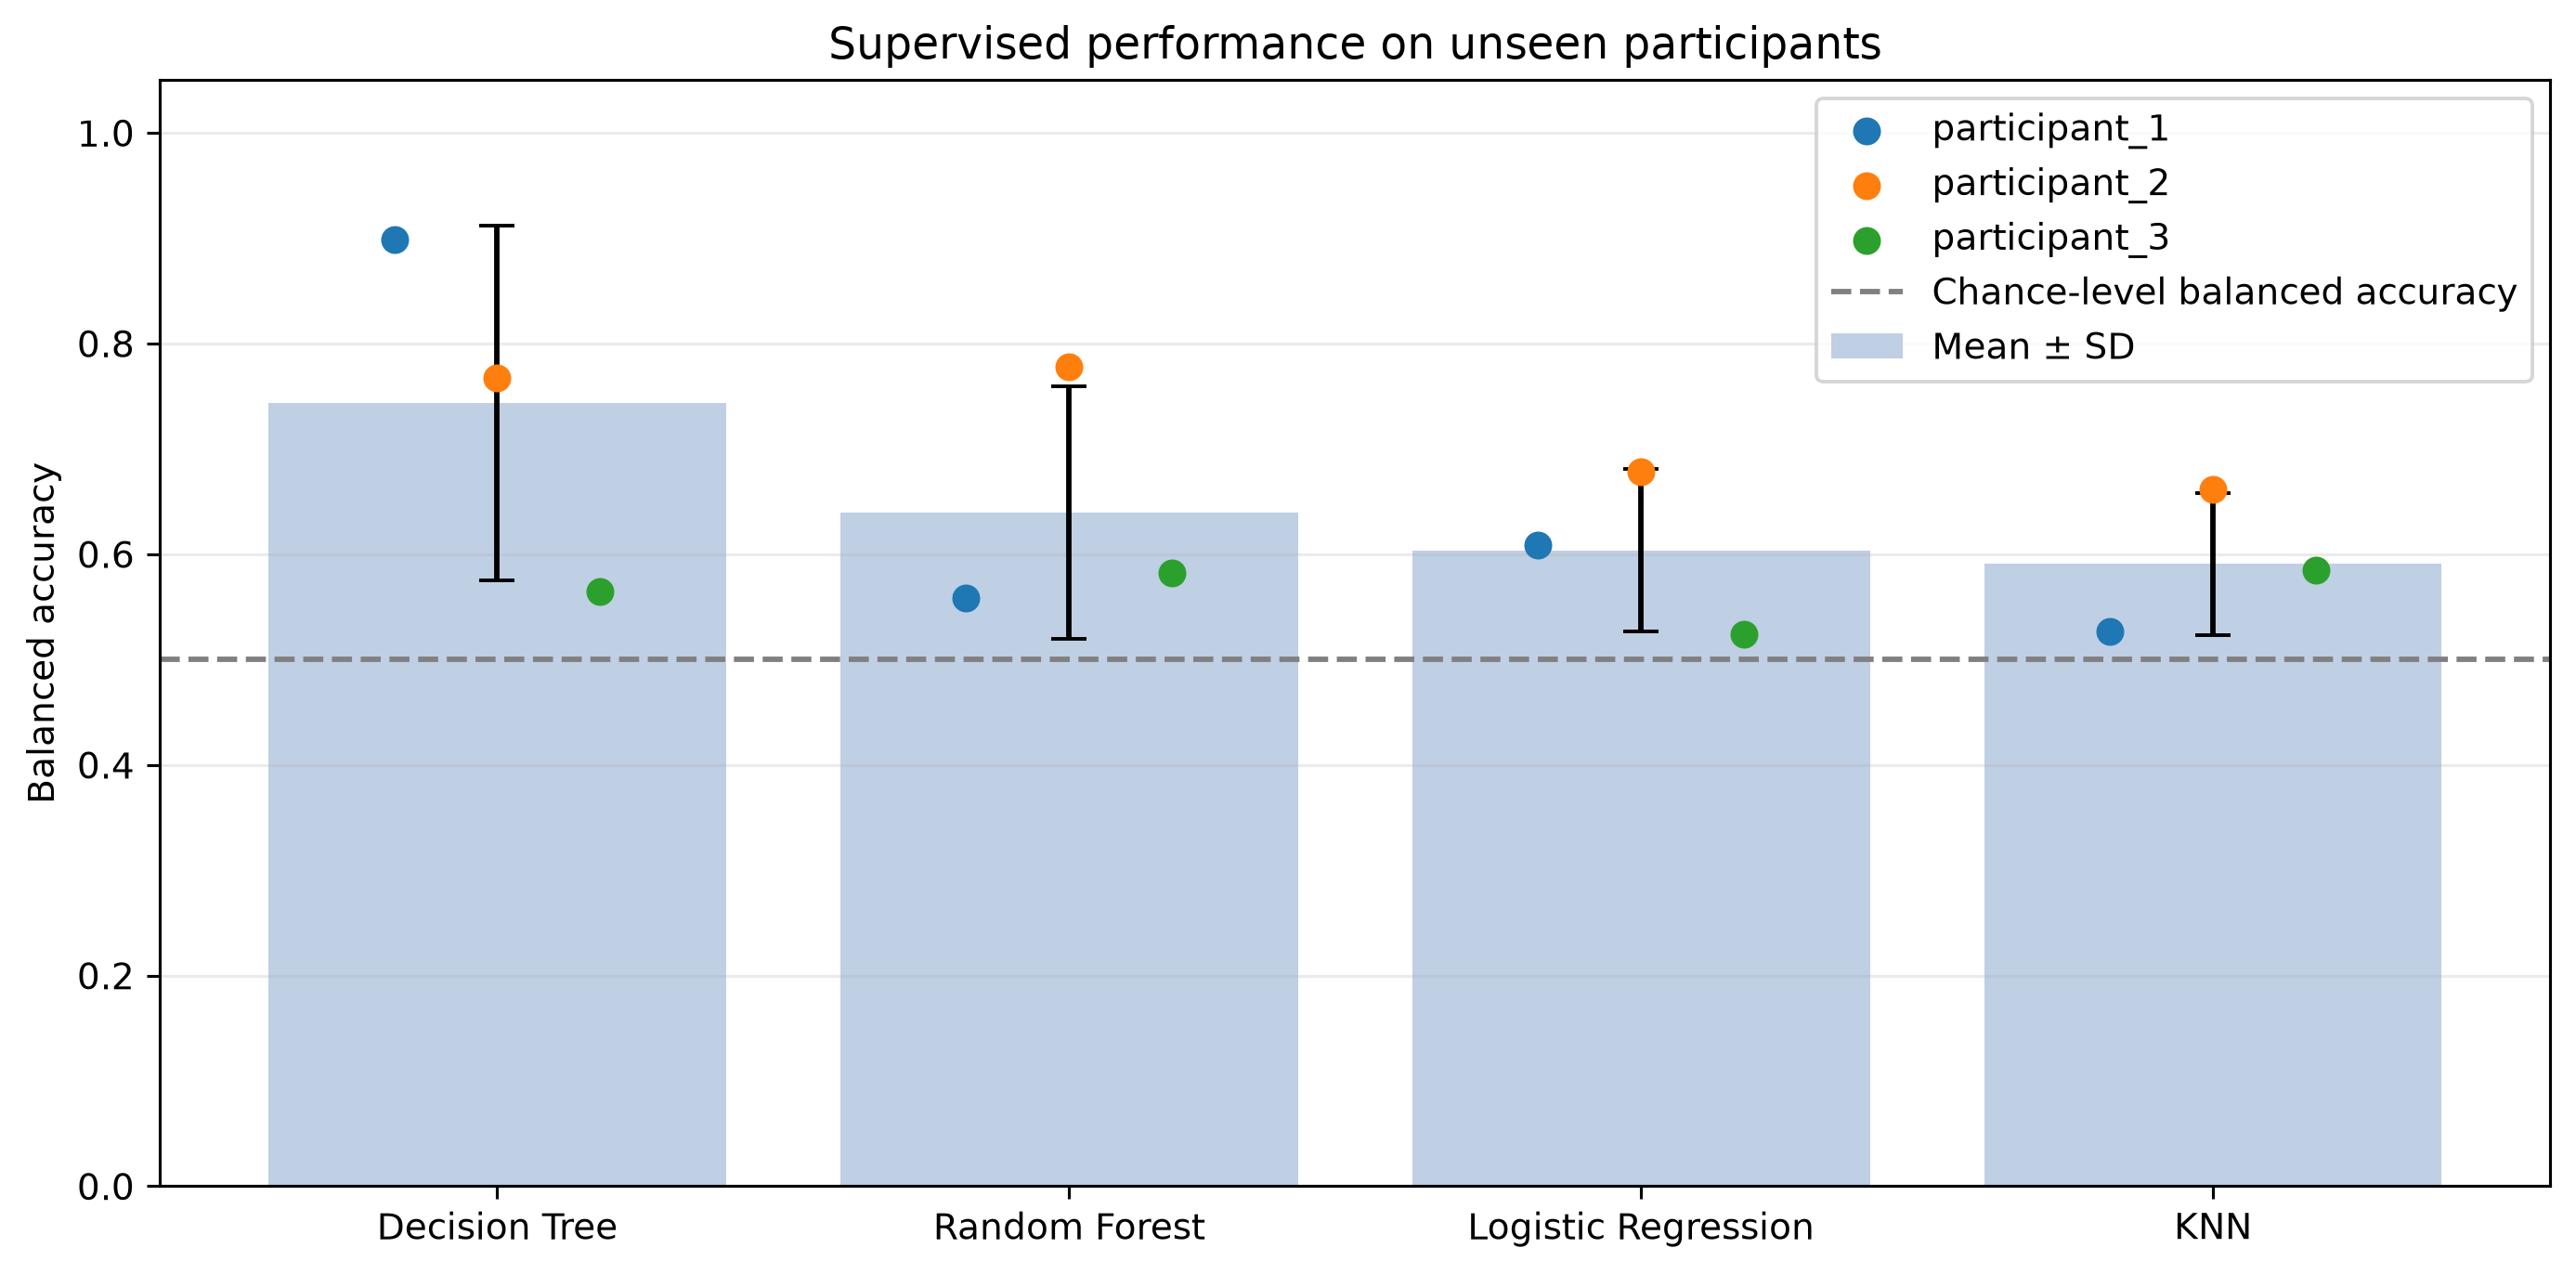

In [26]:
model_order = supervised_summary.index.tolist()
x_positions = np.arange(len(model_order))

means = supervised_summary[("balanced_accuracy", "mean")]
stds = supervised_summary[("balanced_accuracy", "std")]

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(
    x_positions,
    means,
    yerr=stds,
    capsize=5,
    color="lightsteelblue",
    alpha=0.8,
    label="Mean ± SD"
)

offsets = np.linspace(
    -0.18, 0.18, len(participant_performance)
)

for offset, (participant, row) in zip(
    offsets, participant_performance.iterrows()
):
    ax.scatter(
        x_positions + offset,
        row.reindex(model_order).to_numpy(),
        s=45,
        label=participant,
        zorder=3
    )

ax.axhline(
    0.5,
    color="gray",
    linestyle="--",
    label="Chance-level balanced accuracy"
)

ax.set(
    xticks=x_positions,
    xticklabels=model_order,
    ylim=(0, 1.05),
    ylabel="Balanced accuracy",
    title="Supervised performance on unseen participants"
)
ax.legend(loc="best")
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

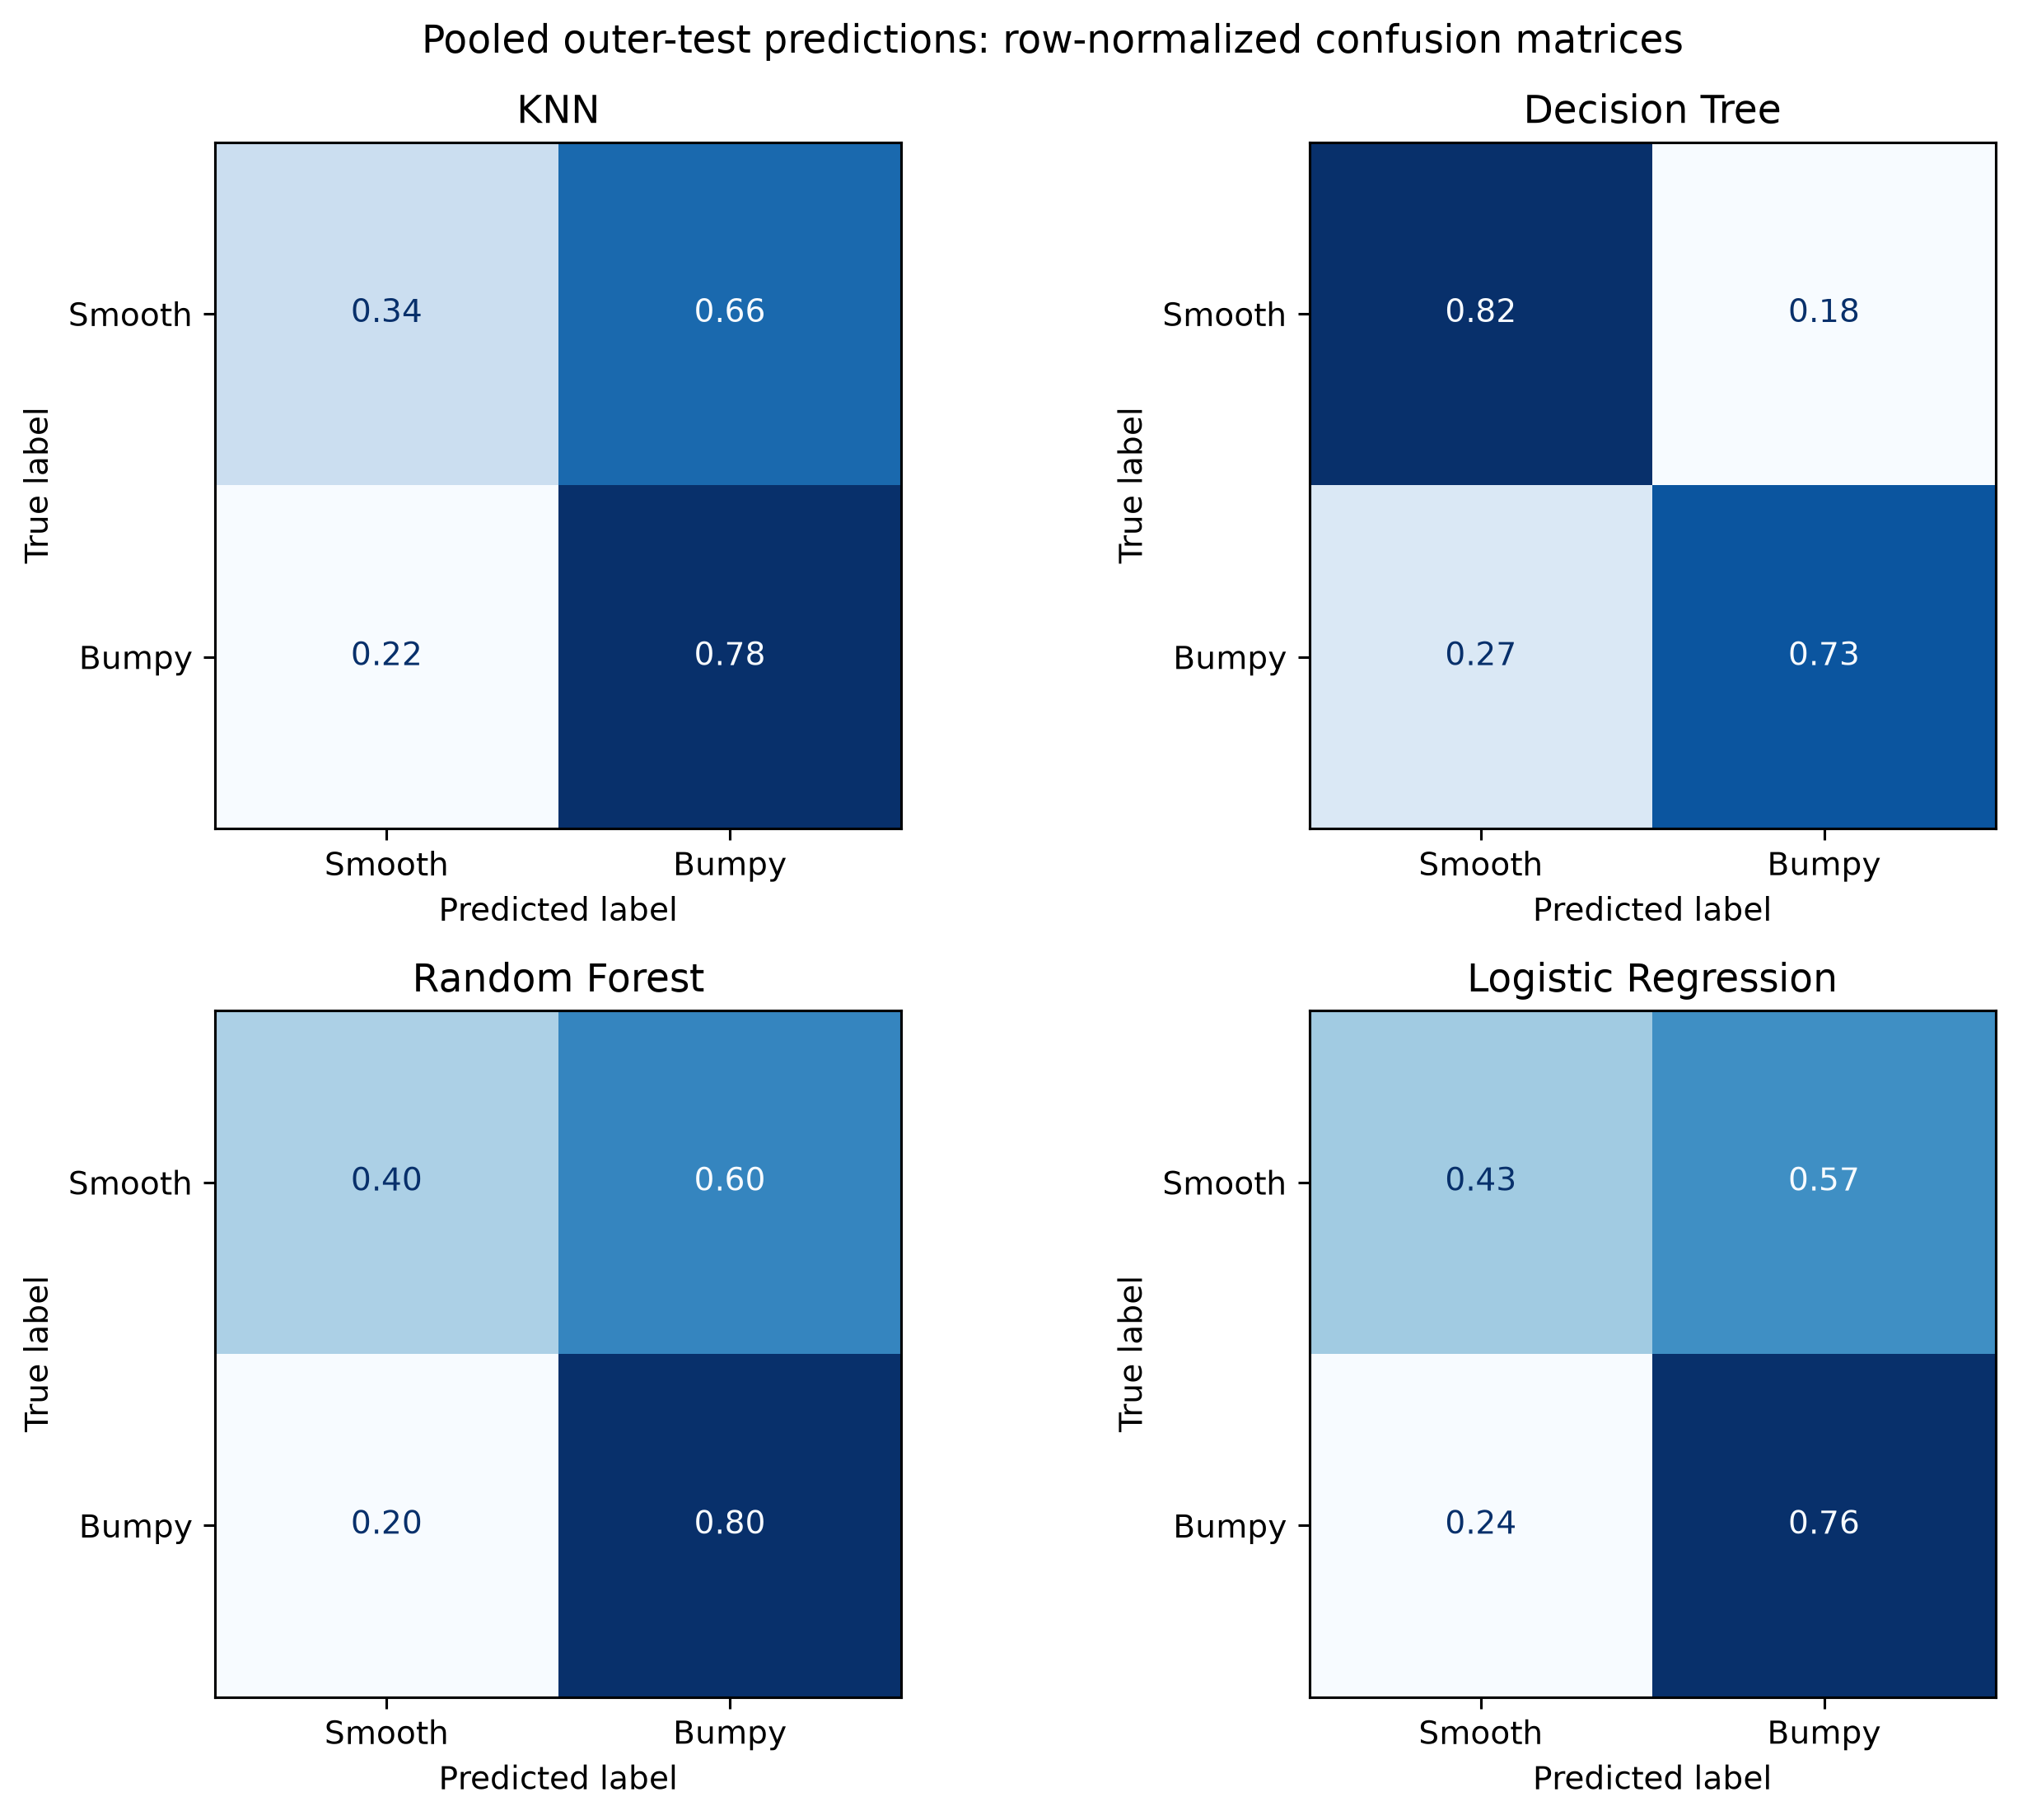

In [27]:
prediction_sets = {
    "KNN": (knn_true, knn_pred),
    "Decision Tree": (tree_true, tree_pred),
    "Random Forest": (rf_true, rf_pred),
    "Logistic Regression": (lr_true, lr_pred)
}

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for ax, (model_name, (true_labels, predicted_labels)) in zip(
    axes.ravel(), prediction_sets.items()
):
    ConfusionMatrixDisplay.from_predictions(
        true_labels,
        predicted_labels,
        labels=[0, 1],
        display_labels=["Smooth", "Bumpy"],
        normalize="true",
        values_format=".2f",
        cmap="Blues",
        colorbar=False,
        ax=ax
    )
    ax.set_title(model_name)

fig.suptitle("Pooled outer-test predictions: row-normalized confusion matrices")
plt.tight_layout()
plt.show()

##### Feature Selection Analysis

The tables list features selected using each outer training set, together with their mutual-information scores. The frequency chart shows how consistently features are selected across three folds; acceleration and gyroscope statistics describe movement, while gravity-axis features may also reflect phone orientation.


Identical feature selections across models within each fold: True

Feature selection: Decision Tree

Held-out participant: participant_1
Scores calculated using the other participants only.


,feature,mutual_information
0,gravity_z_mean,0.1470
1,gravity_y_mean,0.1251
2,acc_z_std,0.1169
3,gravity_x_mean,0.1009
4,acc_magnitude_rms,0.0986
5,acc_magnitude_mean,0.0927
6,acc_magnitude_std,0.0761
7,acc_magnitude_max,0.0757
8,acc_x_std,0.0608
9,acc_y_std,0.0562



Held-out participant: participant_2
Scores calculated using the other participants only.


,feature,mutual_information
0,acc_magnitude_std,0.2271
1,acc_z_std,0.2270
2,acc_magnitude_mean,0.2215
3,acc_magnitude_rms,0.2148
4,acc_magnitude_max,0.2003
5,acc_y_std,0.1815
6,gravity_x_mean,0.1774
7,acc_x_std,0.1711
8,gravity_y_mean,0.1368
9,gyro_magnitude_max,0.1170



Held-out participant: participant_3
Scores calculated using the other participants only.


,feature,mutual_information
0,acc_magnitude_mean,0.3864
1,acc_magnitude_rms,0.3768
2,acc_z_std,0.3562
3,acc_magnitude_std,0.3558
4,acc_magnitude_max,0.3415
5,acc_y_std,0.3116
6,acc_x_std,0.2370
7,gyro_magnitude_max,0.1866
8,gravity_y_mean,0.1725
9,gyro_magnitude_std,0.1465



Selection frequency across 3 outer folds:


,selected_folds,mean_training_MI,selection_rate
feature,,,
acc_magnitude_mean,3,0.2335,1.0000
acc_z_std,3,0.2334,1.0000
acc_magnitude_rms,3,0.2301,1.0000
acc_magnitude_std,3,0.2196,1.0000
acc_magnitude_max,3,0.2058,1.0000
acc_y_std,3,0.1831,1.0000
acc_x_std,3,0.1563,1.0000
gravity_y_mean,3,0.1448,1.0000
gravity_x_mean,2,0.1380,0.6667


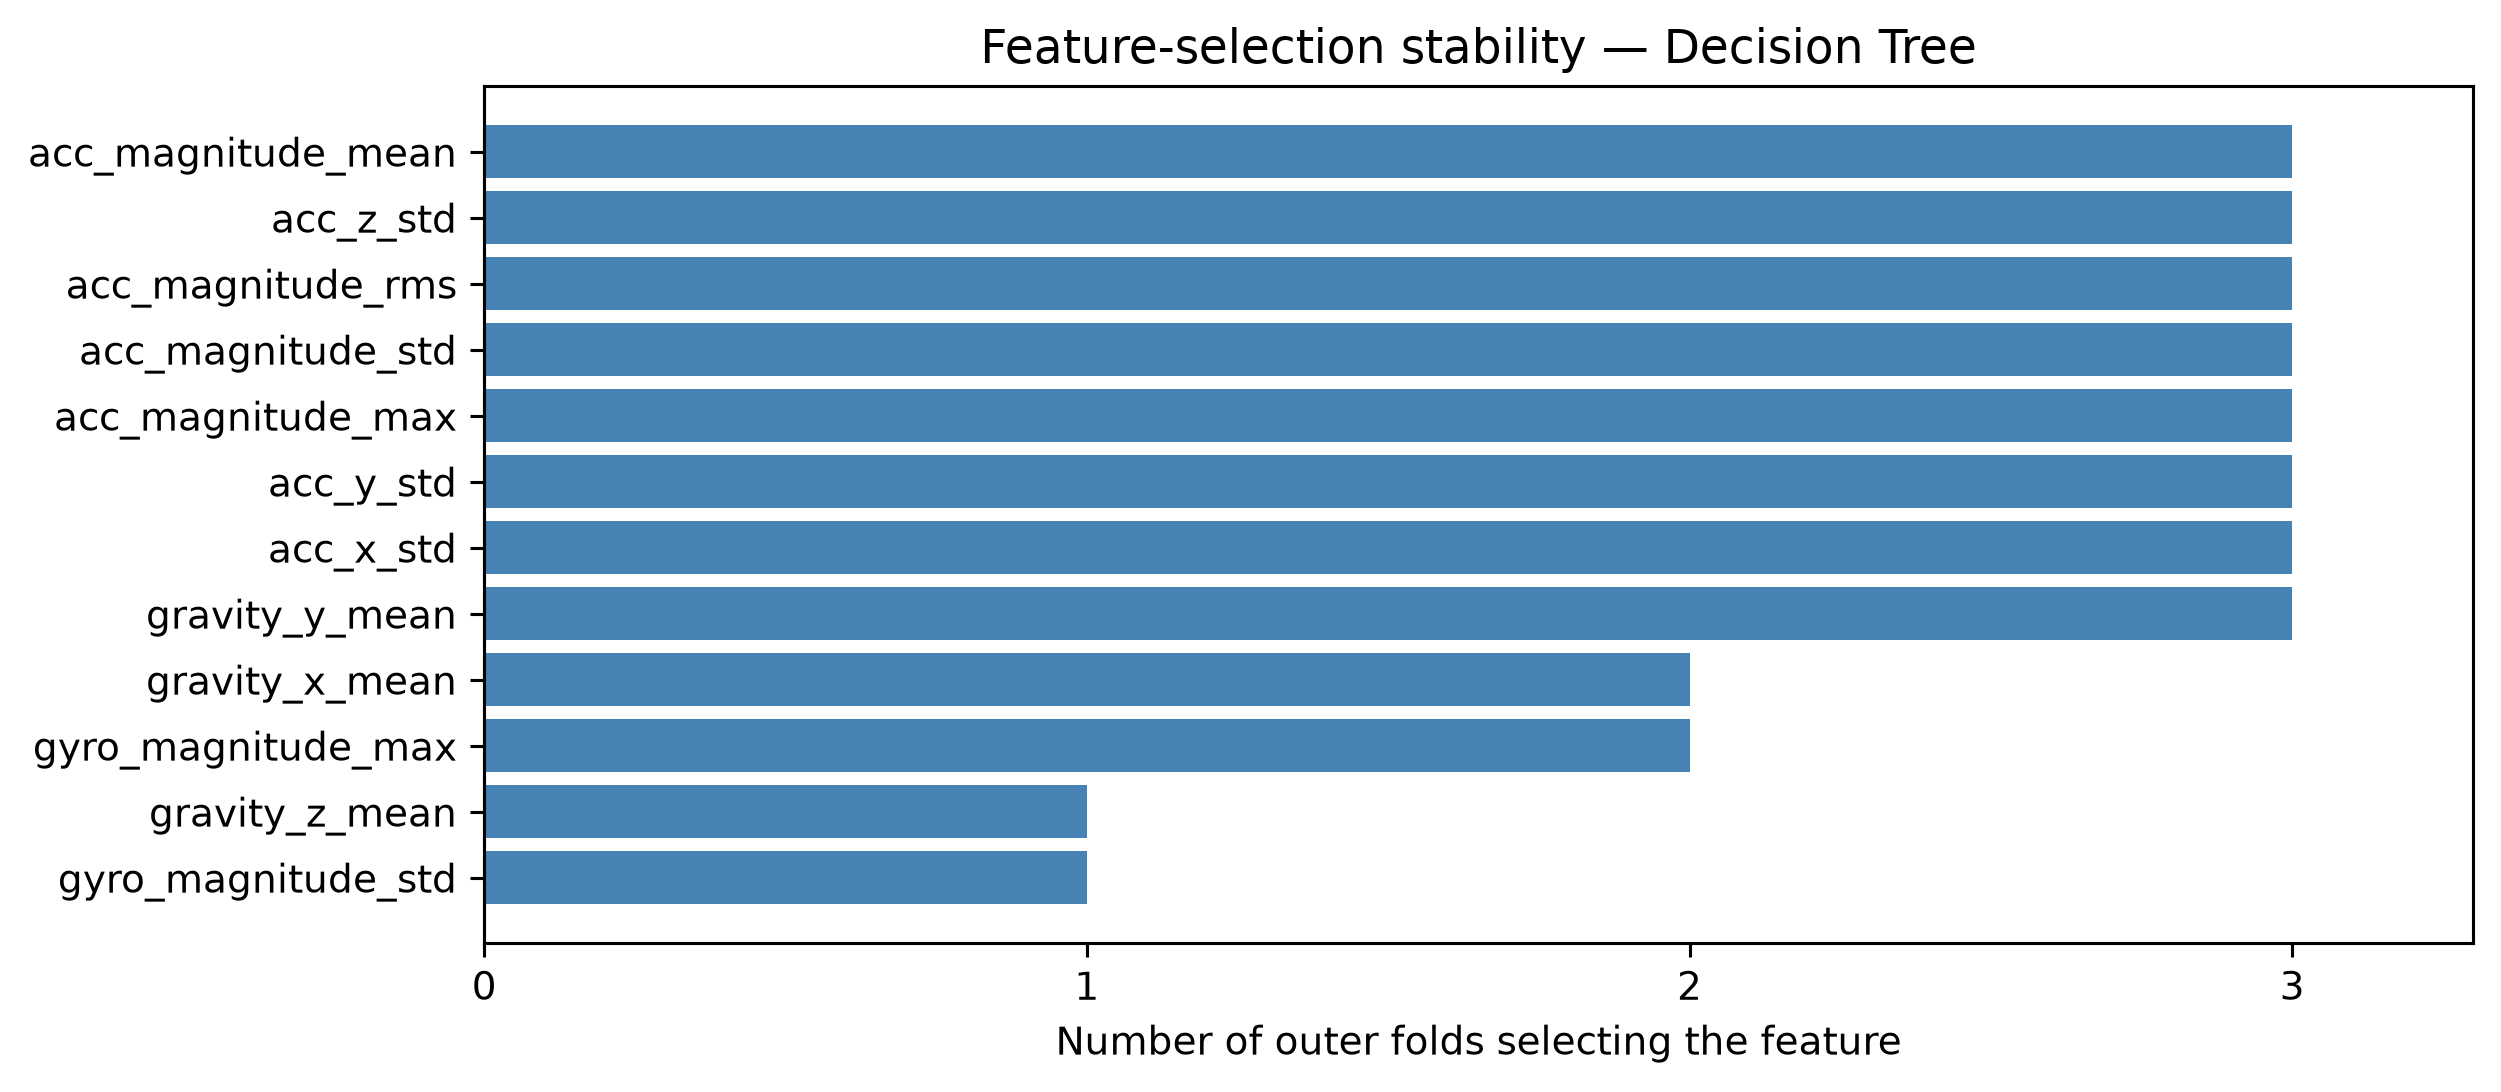

In [28]:
# Collect feature-selection evidence from all outer training folds.
selection_rows = []

for results in [knn_results, tree_results, rf_results, lr_results]:
    for _, fold in results.iterrows():
        selected = set(fold["selected_features"])

        for feature, score in fold["feature_scores"].items():
            selection_rows.append({
                "model": fold["model"],
                "held_out_participant": fold["held_out_participant"],
                "feature": feature,
                "mutual_information": score,
                "selected": feature in selected
            })

feature_selection_details = pd.DataFrame(selection_rows)

# With the current fixed k=10 and deterministic MI selector,
# all four models should select the same features within each fold.
selection_agreement = (
    feature_selection_details
    .groupby(["held_out_participant", "feature"])["selected"]
    .nunique()
    .eq(1)
    .all()
)

print(
    "Identical feature selections across models within each fold:",
    selection_agreement
)

# Show one representative model when selections are identical.
# Otherwise, show each model separately.
models_to_show = (
    ["Decision Tree"]
    if selection_agreement
    else feature_selection_details["model"].unique().tolist()
)

for model_name in models_to_show:
    model_details = feature_selection_details.loc[
        feature_selection_details["model"] == model_name
    ]

    print(f"\nFeature selection: {model_name}")

    # Selected features and MI scores for each outer training fold.
    for participant, fold in model_details.groupby(
        "held_out_participant"
    ):
        print(f"\nHeld-out participant: {participant}")
        print("Scores calculated using the other participants only.")

        display(
            fold.loc[
                fold["selected"],
                ["feature", "mutual_information"]
            ]
            .sort_values("mutual_information", ascending=False)
            .reset_index(drop=True)
            .round(4)
        )

    # Count selection across the three outer folds.
    stability = (
        model_details.groupby("feature")
        .agg(
            selected_folds=("selected", "sum"),
            mean_training_MI=("mutual_information", "mean")
        )
        .sort_values(
            ["selected_folds", "mean_training_MI"],
            ascending=False
        )
    )

    n_folds = model_details["held_out_participant"].nunique()
    stability["selection_rate"] = (
        stability["selected_folds"] / n_folds
    )

    print(f"\nSelection frequency across {n_folds} outer folds:")
    display(stability.round(4))

    # Visualize features selected at least once.
    plotted = stability.loc[
        stability["selected_folds"] > 0
    ].sort_values(
        ["selected_folds", "mean_training_MI"]
    )

    fig, ax = plt.subplots(
        figsize=(9, max(4, len(plotted) * 0.3))
    )

    ax.barh(
        plotted.index,
        plotted["selected_folds"],
        color="steelblue"
    )
    ax.set(
        xlabel="Number of outer folds selecting the feature",
        ylabel="",
        title=f"Feature-selection stability — {model_name}",
        xticks=np.arange(n_folds + 1),
        xlim=(0, n_folds + 0.3)
    )

    plt.tight_layout()
    plt.show()

### 6.2 Unsupervised Learning

Unlike supervised models, unsupervised models are trained without smooth/bumpy target labels. They identify structure in the sensor-feature space independently. The known road-condition labels are used only afterward to interpret and evaluate the discovered clusters.


#### 6.2.1 Self-Organizing Map

SOM maps standardized windows onto a 6 × 6 grid of learned feature patterns without using road labels. Each window receives its closest node’s ID; these 36 possible nodes are not predefined smooth or bumpy classes.


In [29]:
from minisom import MiniSom

# Standardize all sensor features from Section 5.1.
som_scaler = StandardScaler()
X_som = som_scaler.fit_transform(X)

# Train a 6 × 6 map without road-condition labels.
som = MiniSom(
    x=6,
    y=6,
    input_len=X_som.shape[1],
    sigma=1.5,
    learning_rate=0.5,
    random_seed=42
)

som.random_weights_init(X_som)
som.train_random(X_som, num_iteration=10000)

# Save each window's winning node for later visualization.
som_winners = np.array([
    som.winner(window)
    for window in X_som
])

som_node_ids = np.ravel_multi_index(
    som_winners.T,
    dims=(6, 6)
)

##### Discussion

All 36 SOM nodes received windows, with some nodes dominated by one road condition or participant. However, road ARI was only 0.036, indicating weak overall agreement with the road labels. The low silhouette score (0.080) describes separation between individual nodes. This fine partition should not be interpreted as directly equivalent to the two groups produced by K-Means or GMM.


#### 6.2.2 DBSCAN

DBSCAN groups windows according to regions of high feature density and can identify isolated windows as noise. Because DBSCAN is distance-based, the sensor features are standardized before clustering.

In [30]:
# Scale all numerical features
dbscan_scaler = StandardScaler()

X_dbscan = dbscan_scaler.fit_transform(X)

print("Windows used:", X_dbscan.shape[0])
print("Features used:", X_dbscan.shape[1])

Windows used: 1941
Features used: 26


In [31]:
dbscan_results = []

eps_values = [1.5, 2.0, 2.5, 3.0, 3.5]
min_samples_values = [5, 10, 20]

for eps in eps_values:
    for dbscan_min_samples in min_samples_values:

        dbscan = DBSCAN(
            eps=eps,
            min_samples=dbscan_min_samples
        )

        cluster_labels = dbscan.fit_predict(
            X_dbscan
        )

        # -1 represents noise
        non_noise_mask = cluster_labels != -1

        n_clusters = len(
            set(cluster_labels) - {-1}
        )

        noise_percentage = (
            (~non_noise_mask).mean() * 100
        )

        # Silhouette requires at least 2 clusters
        if (
            n_clusters >= 2
            and non_noise_mask.sum() > n_clusters
        ):
            silhouette = silhouette_score(
                X_dbscan[non_noise_mask],
                cluster_labels[non_noise_mask]
            )
        else:
            silhouette = np.nan

        dbscan_results.append({
            "eps": eps,
            "min_samples": dbscan_min_samples,
            "clusters": n_clusters,
            "noise_percent": noise_percentage,
            "silhouette_score": silhouette
        })

dbscan_results_df = pd.DataFrame(
    dbscan_results
)

display(
    dbscan_results_df.round(3)
)

,eps,min_samples,clusters,noise_percent,silhouette_score
0,1.5,5,7,50.077,0.193
1,1.5,10,7,55.951,0.279
2,1.5,20,4,66.306,0.382
3,2.0,5,6,29.315,0.245
4,2.0,10,5,32.921,0.259
5,2.0,20,4,38.691,0.276
6,2.5,5,5,17.311,0.336
7,2.5,10,4,19.990,0.351
8,2.5,20,3,24.060,0.357
9,3.0,5,4,9.737,0.371


In [32]:
dbscan = DBSCAN(
    eps=3.0,
    min_samples=5
)

dbscan_labels = dbscan.fit_predict(
    X_dbscan
)

dbscan_features = features_df.copy()
dbscan_features["cluster"] = dbscan_labels

print(
    "Number of clusters:",
    len(set(dbscan_labels) - {-1})
)

print(
    "Noise windows:",
    (dbscan_labels == -1).sum()
)

Number of clusters: 4
Noise windows: 189


In [33]:
cluster_sizes = (
    dbscan_features["cluster"]
    .value_counts()
    .sort_index()
)

display(
    cluster_sizes.rename("windows").to_frame()
)

cluster_condition_table = pd.crosstab(
    dbscan_features["cluster"],
    dbscan_features["road_condition"],
    normalize="index"
) * 100

display(
    cluster_condition_table.round(1)
)

,windows
cluster,
-1,189
0,1523
1,83
2,138
3,8


road_condition,bumpy,smooth
cluster,,
-1,83.6,16.4
0,60.1,39.9
1,100.0,0.0
2,63.8,36.2
3,100.0,0.0


In [34]:
cluster_participant_table = pd.crosstab(
    dbscan_features["cluster"],
    dbscan_features["participant"],
    normalize="index"
) * 100

display(
    cluster_participant_table.round(1)
)

participant,participant_1,participant_2,participant_3
cluster,,,
-1,33.3,39.2,27.5
0,61.3,6.3,32.4
1,0.0,100.0,0.0
2,0.0,100.0,0.0
3,0.0,100.0,0.0


##### Discussion

DBSCAN found four clusters and marked 189 windows (9.7%) as noise. Its largest cluster mixed both road conditions, while the other three clusters contained only participant_2 windows. Participant ARI (0.255) exceeded road ARI (−0.029), suggesting participant-related structure. The reported clustering scores exclude noise, so they describe only 90.3% of the dataset and require coverage-aware comparison.


#### 6.2.3 K-Means

K-Means divides the standardized windows into two groups by minimizing distances to their cluster centers. Two groups are specified in advance, but their numerical labels do not automatically represent smooth and bumpy roads.


In [35]:
# Reuse the standardized features created in the DBSCAN section.
kmeans = KMeans(
    n_clusters=2,
    n_init=20,
    max_iter=500,
    random_state=42
)

kmeans_labels = kmeans.fit_predict(X_dbscan)

kmeans_features = features_df.copy()
kmeans_features["cluster"] = kmeans_labels

print("Iterations:", kmeans.n_iter_)
print("Inertia:", round(kmeans.inertia_, 3))

Iterations: 14
Inertia: 39321.913


##### Discussion

K-Means achieved the highest silhouette score (0.400), but road ARI was −0.029. Its smaller cluster contained 95.2% bumpy windows, while the larger cluster mixed both conditions. The model therefore isolated a predominantly bumpy subset without consistently separating all smooth and bumpy windows. Clear separation in feature space did not translate into agreement with the road labels.


#### 6.2.4 Gaussian Mixture Model

GMM represents the standardized features using two Gaussian components and assigns each window to its most probable component. Its membership probabilities describe these components, not verified probabilities of smooth or bumpy roads.


In [36]:
gmm = GaussianMixture(
    n_components=2,
    covariance_type="diag",
    n_init=10,
    max_iter=500,
    reg_covar=1e-6,
    random_state=42
)

gmm.fit(X_dbscan)

print("Converged:", gmm.converged_)
print("Iterations:", gmm.n_iter_)

if not gmm.converged_:
    raise RuntimeError(
        "GMM did not converge. Resolve this before interpreting results."
    )

gmm_labels = gmm.predict(X_dbscan)
gmm_probabilities = gmm.predict_proba(X_dbscan)

gmm_features = features_df.copy()
gmm_features["cluster"] = gmm_labels

probability_table = pd.DataFrame(
    gmm_probabilities,
    columns=["probability_cluster_0", "probability_cluster_1"],
    index=X.index
)

print("\nExample component-membership probabilities:")
display(probability_table.head().round(3))

Converged: True
Iterations: 9

Example component-membership probabilities:


,probability_cluster_0,probability_cluster_1
0,1.000,0.000
1,0.000,1.000
2,0.001,0.999
3,1.000,0.000
4,0.872,0.128


##### Discussion

GMM converged after nine iterations and achieved a road ARI of 0.035, indicating weak agreement with road conditions. One component contained 86.7% bumpy windows, while the other remained mixed. Its silhouette score (0.291) was below K-Means. Convergence confirms that the fitting procedure stopped successfully; it does not establish that the components correspond to the intended road classes.


#### 6.2.5 Performance of Unsupervised Learning

The score table separates cluster clarity (silhouette) from agreement with road labels (ARI and NMI). K-Means has the highest silhouette (0.400), but all road ARI values are close to zero. SOM uses 36 node groups, and DBSCAN excludes noise from its scores, so group count and coverage matter when comparing models.

The composition tables and stacked bars show the smooth/bumpy percentages within each group. Mixed colors indicate mixed road labels. Each bar totals 100% regardless of group size; use the window counts to judge how much data each group represents.


In [37]:
from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
    silhouette_score
)

assert X_som.shape == X_dbscan.shape
assert np.allclose(X_som, X_dbscan), (
    "SOM and the other models use different standardized features. "
    "Rerun Section 6.2 in order."
)

clustering_predictions = {
    "SOM (map nodes)": som_node_ids,
    "DBSCAN": dbscan_labels,
    "K-Means": kmeans_labels,
    "Gaussian Mixture": gmm_labels
}

clustering_frames = {}
evaluation_rows = []

for model_name, labels in clustering_predictions.items():
    labels = np.asarray(labels)

    if labels.ndim != 1 or len(labels) != len(X_dbscan):
        raise ValueError(
            f"{model_name}: cluster labels do not match the feature rows."
        )

    frame = features_df.copy()
    frame["cluster"] = labels
    clustering_frames[model_name] = frame

    # DBSCAN labels noise as -1.
    non_noise = labels != -1
    evaluated_labels = labels[non_noise]
    n_evaluated = int(non_noise.sum())
    n_clusters = len(np.unique(evaluated_labels))

    silhouette = np.nan
    road_ari = np.nan
    road_nmi = np.nan
    participant_ari = np.nan

    if 2 <= n_clusters < n_evaluated:
        silhouette = silhouette_score(
            X_dbscan[non_noise],
            evaluated_labels
        )

    # External labels are used only for evaluation after clustering.
    if n_evaluated >= 2:
        road_ari = adjusted_rand_score(
            y.to_numpy()[non_noise],
            evaluated_labels
        )

        road_nmi = normalized_mutual_info_score(
            y.to_numpy()[non_noise],
            evaluated_labels
        )

        participant_ari = adjusted_rand_score(
            features_df["participant"].to_numpy()[non_noise],
            evaluated_labels
        )

    evaluation_rows.append({
        "model": model_name,
        "clusters": n_clusters,
        "evaluated_windows": n_evaluated,
        "coverage_percent": non_noise.mean() * 100,
        "noise_percent": (~non_noise).mean() * 100,
        "silhouette": silhouette,
        "road_ARI": road_ari,
        "road_NMI": road_nmi,
        "participant_ARI": participant_ari
    })

unsupervised_summary = (
    pd.DataFrame(evaluation_rows)
    .set_index("model")
)

print("Unsupervised model performance")
print(
    "DBSCAN noise is excluded from silhouette, ARI and NMI. "
    "Consider coverage when comparing models."
)
display(unsupervised_summary.round(3))

Unsupervised model performance
DBSCAN noise is excluded from silhouette, ARI and NMI. Consider coverage when comparing models.


,clusters,evaluated_windows,coverage_percent,noise_percent,silhouette,road_ARI,road_NMI,participant_ARI
model,,,,,,,,
SOM (map nodes),36,1941,100.000,0.000,0.080,0.036,0.144,0.097
DBSCAN,4,1752,90.263,9.737,0.371,-0.029,0.044,0.255
K-Means,2,1941,100.000,0.000,0.400,-0.029,0.109,0.055
Gaussian Mixture,2,1941,100.000,0.000,0.291,0.035,0.094,0.137


In [38]:
for model_name, frame in clustering_frames.items():
    print(f"\n{model_name}")

    cluster_sizes = (
        frame.groupby("cluster")
        .size()
        .rename("windows")
    )

    road_percent = pd.crosstab(
        frame["cluster"],
        frame["road_condition"],
        normalize="index"
    ).reindex(
        columns=["smooth", "bumpy"],
        fill_value=0
    ) * 100

    participant_percent = pd.crosstab(
        frame["cluster"],
        frame["participant"],
        normalize="index"
    ) * 100

    composition_table = (
        cluster_sizes.to_frame()
        .join(road_percent.add_suffix("_percent"))
        .join(participant_percent.add_suffix("_percent"))
    )

    print("Cluster composition; -1 denotes DBSCAN noise:")
    display(composition_table.round(1))


SOM (map nodes)
Cluster composition; -1 denotes DBSCAN noise:


,windows,smooth_percent,bumpy_percent,participant_1_percent,participant_2_percent,participant_3_percent
cluster,,,,,,
0,8,25.0,75.0,50.0,25.0,25.0
1,32,3.1,96.9,0.0,100.0,0.0
2,38,2.6,97.4,0.0,100.0,0.0
3,14,0.0,100.0,7.1,92.9,0.0
4,70,0.0,100.0,94.3,1.4,4.3
5,44,0.0,100.0,0.0,100.0,0.0
6,28,21.4,78.6,46.4,28.6,25.0
7,32,28.1,71.9,0.0,100.0,0.0
8,23,21.7,78.3,0.0,100.0,0.0



DBSCAN
Cluster composition; -1 denotes DBSCAN noise:


,windows,smooth_percent,bumpy_percent,participant_1_percent,participant_2_percent,participant_3_percent
cluster,,,,,,
-1,189,16.4,83.6,33.3,39.2,27.5
0,1523,39.9,60.1,61.3,6.3,32.4
1,83,0.0,100.0,0.0,100.0,0.0
2,138,36.2,63.8,0.0,100.0,0.0
3,8,0.0,100.0,0.0,100.0,0.0



K-Means
Cluster composition; -1 denotes DBSCAN noise:


,windows,smooth_percent,bumpy_percent,participant_1_percent,participant_2_percent,participant_3_percent
cluster,,,,,,
0,375,4.8,95.2,47.7,45.9,6.4
1,1566,42.8,57.2,52.2,14.5,33.3



Gaussian Mixture
Cluster composition; -1 denotes DBSCAN noise:


,windows,smooth_percent,bumpy_percent,participant_1_percent,participant_2_percent,participant_3_percent
cluster,,,,,,
0,660,13.3,86.7,41.1,47.4,11.5
1,1281,46.9,53.1,56.6,6.7,36.7


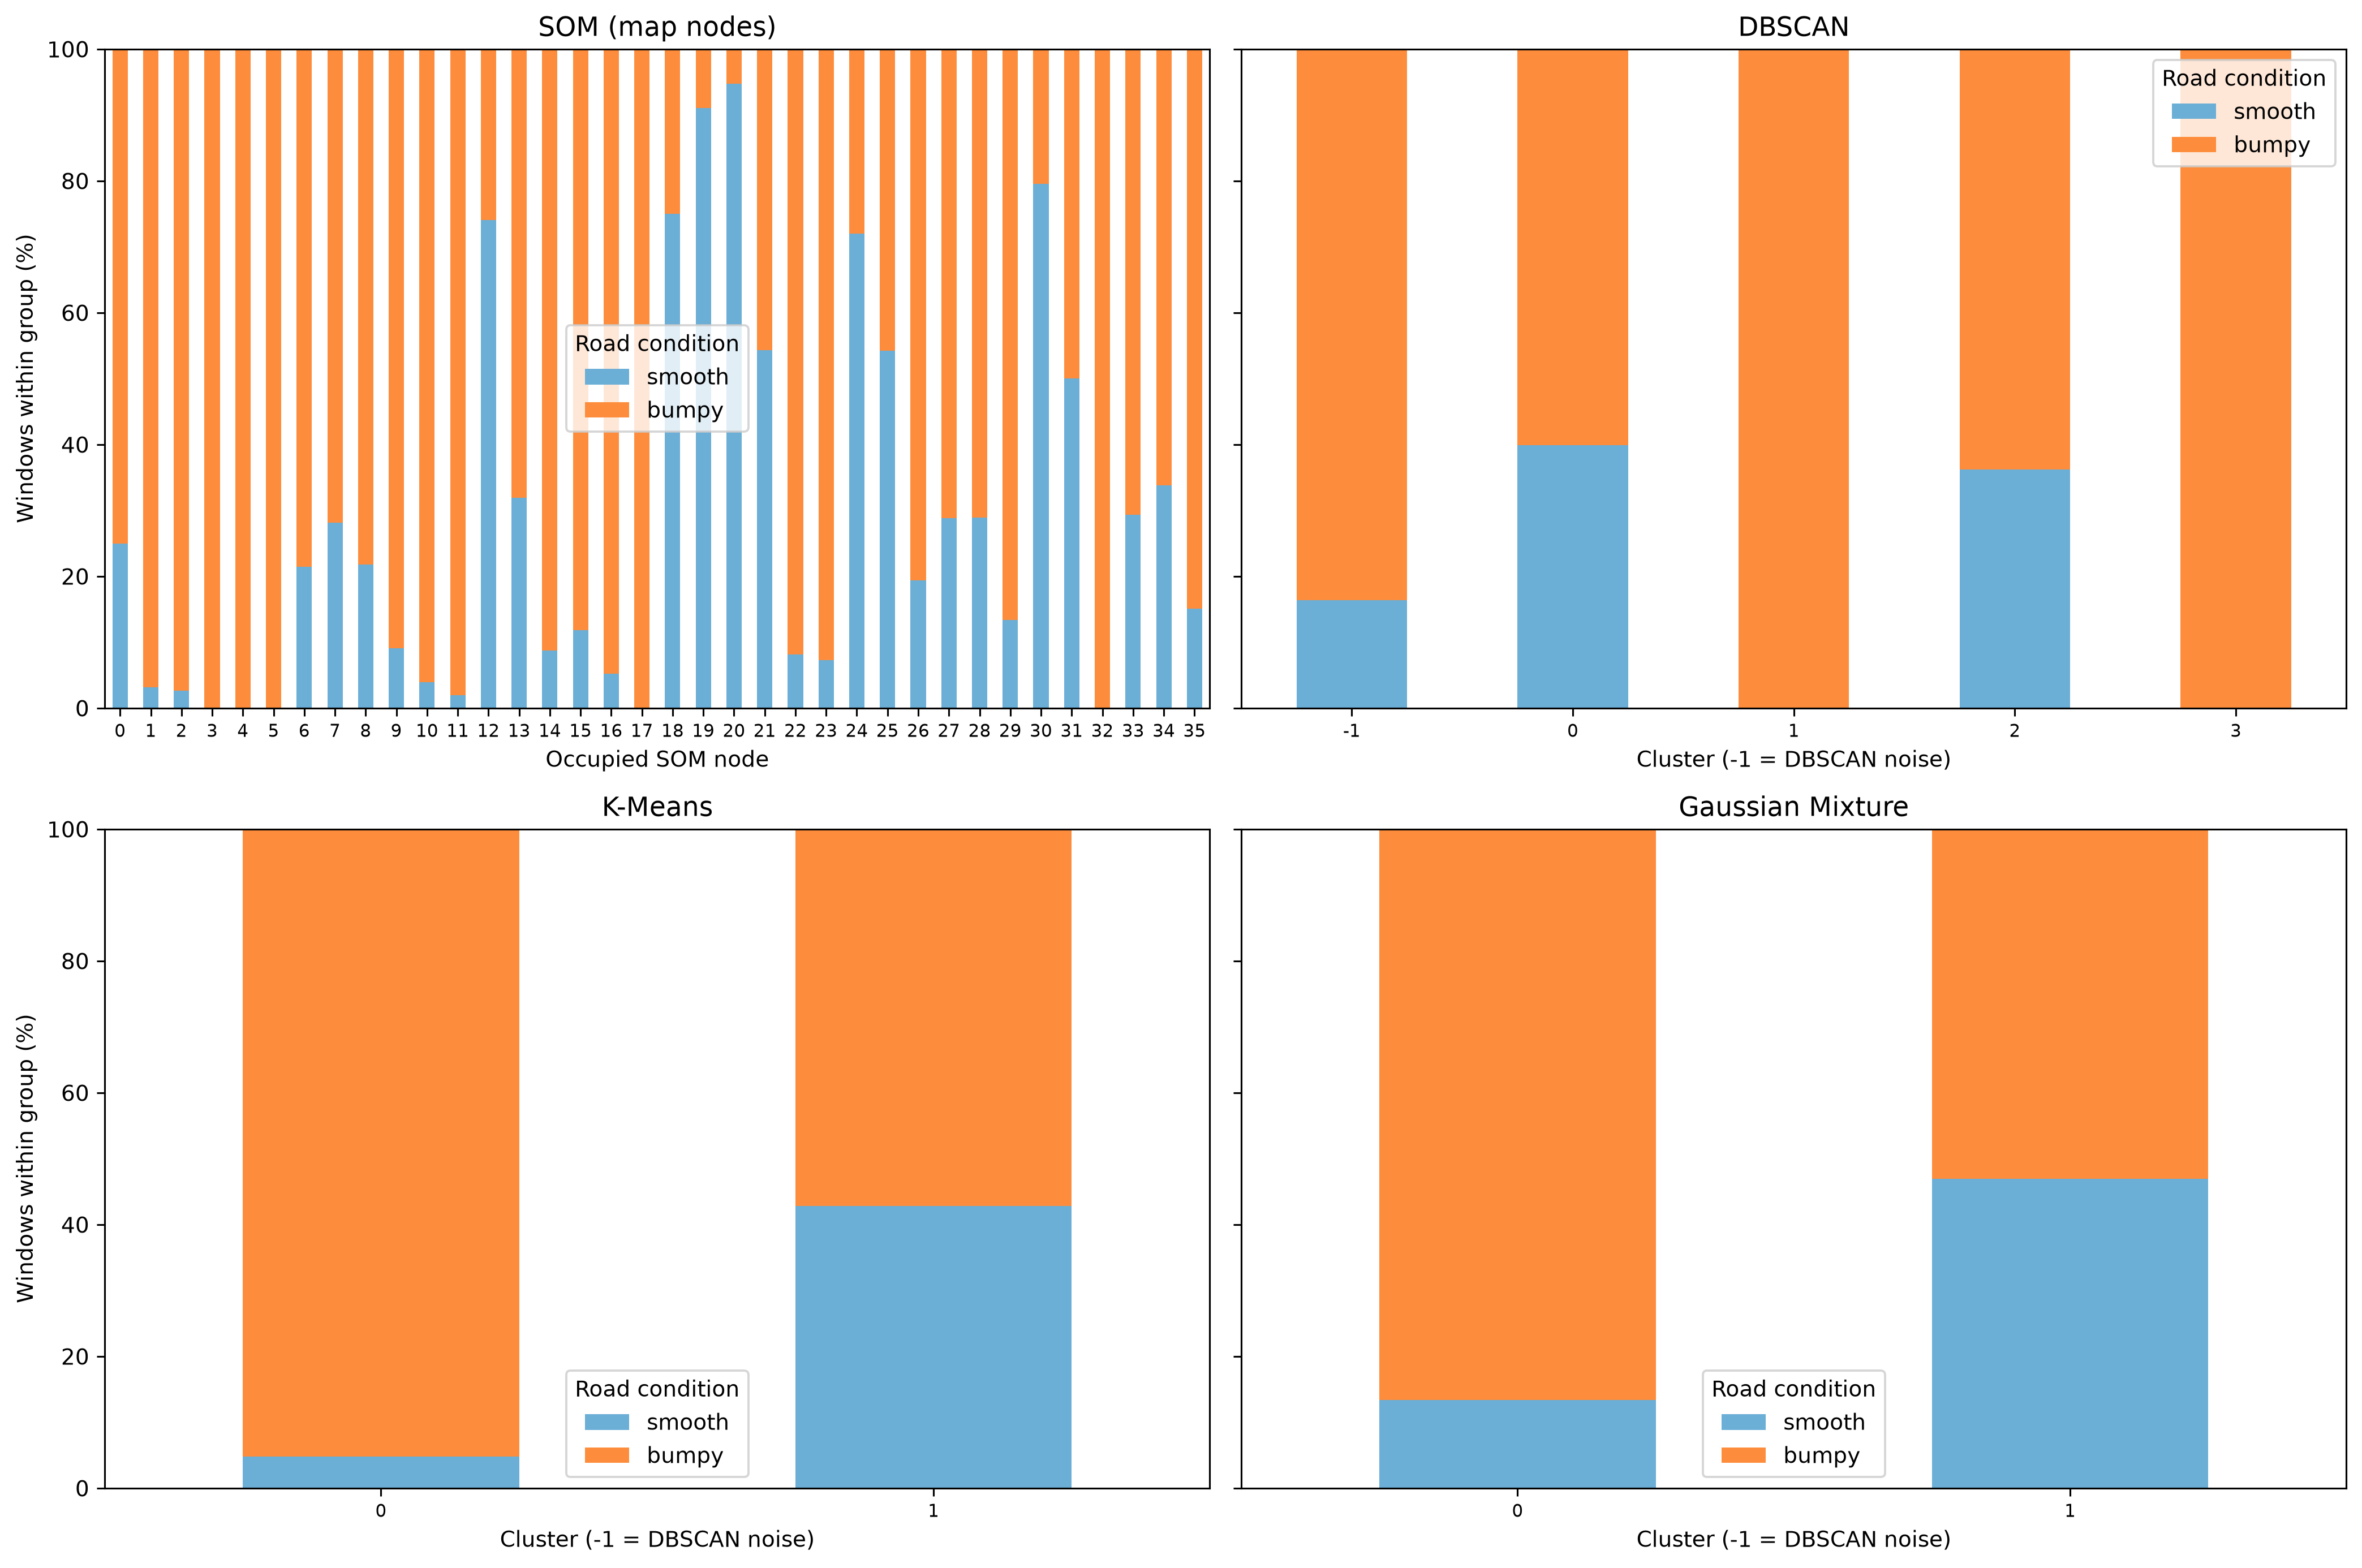

In [39]:
fig, axes = plt.subplots(
    2, 2,
    figsize=(15, 10),
    sharey=True
)

for ax, (model_name, frame) in zip(
    axes.ravel(),
    clustering_frames.items()
):
    composition = pd.crosstab(
        frame["cluster"],
        frame["road_condition"],
        normalize="index"
    ).reindex(
        columns=["smooth", "bumpy"],
        fill_value=0
    ) * 100

    composition.plot(
        kind="bar",
        stacked=True,
        color=["#6BAED6", "#FD8D3C"],
        rot=0,
        ax=ax
    )

    ax.set(
        title=model_name,
        xlabel=(
            "Occupied SOM node"
            if model_name == "SOM (map nodes)"
            else "Cluster (-1 = DBSCAN noise)"
        ),
        ylabel="Windows within group (%)",
        ylim=(0, 100)
    )
    ax.tick_params(axis="x", labelsize=8)
    ax.legend(title="Road condition")

plt.tight_layout()
plt.show()


### 6.3 Model Comparison

The summary below compares supervised prediction on unseen participants with clustering patterns in the available dataset. These are different evaluation tasks, so their scores support separate conclusions rather than a single ranking of all models.


In [40]:
# Summarize the outer LOSO test results.
overall_supervised_folds = pd.concat(
    [knn_results, tree_results, rf_results, lr_results],
    ignore_index=True
)

overall_supervised_summary = (
    overall_supervised_folds
    .groupby("model")
    .agg(
        balanced_accuracy_mean=("balanced_accuracy", "mean"),
        balanced_accuracy_std=("balanced_accuracy", "std"),
        balanced_accuracy_min=("balanced_accuracy", "min"),
        balanced_accuracy_max=("balanced_accuracy", "max"),
        f1_mean=("f1_score", "mean")
    )
    .sort_values(
        "balanced_accuracy_mean",
        ascending=False
    )
)

print("Supervised learning: performance on unseen participants")
display(overall_supervised_summary.round(3))

best_observed_model = overall_supervised_summary.index[0]
best_result = overall_supervised_summary.loc[best_observed_model]

print(
    f"Highest observed mean balanced accuracy: "
    f"{best_observed_model}, "
    f"{best_result['balanced_accuracy_mean']:.3f} "
    f"± {best_result['balanced_accuracy_std']:.3f} SD."
)

print(
    f"Participant-level range: "
    f"{best_result['balanced_accuracy_min']:.3f}–"
    f"{best_result['balanced_accuracy_max']:.3f}."
)

print("\nUnsupervised learning: clustering structure and label agreement")
display(
    unsupervised_summary[
        [
            "clusters",
            "coverage_percent",
            "silhouette",
            "road_ARI",
            "road_NMI",
            "participant_ARI"
        ]
    ].round(3)
)

print(
    "\nSupervised results evaluate prediction on held-out participants. "
    "Unsupervised results describe clustering on the available dataset. "
    "These scores measure different outcomes and should not be "
    "combined into a single model ranking."
)

Supervised learning: performance on unseen participants


,balanced_accuracy_mean,balanced_accuracy_std,balanced_accuracy_min,balanced_accuracy_max,f1_mean
model,,,,,
Decision Tree,0.743,0.168,0.565,0.899,0.728
Random Forest,0.639,0.120,0.559,0.778,0.731
Logistic Regression,0.604,0.077,0.524,0.678,0.664
KNN,0.591,0.067,0.527,0.661,0.710


Highest observed mean balanced accuracy: Decision Tree, 0.743 ± 0.168 SD.
Participant-level range: 0.565–0.899.

Unsupervised learning: clustering structure and label agreement


,clusters,coverage_percent,silhouette,road_ARI,road_NMI,participant_ARI
model,,,,,,
SOM (map nodes),36,100.000,0.080,0.036,0.144,0.097
DBSCAN,4,90.263,0.371,-0.029,0.044,0.255
K-Means,2,100.000,0.400,-0.029,0.109,0.055
Gaussian Mixture,2,100.000,0.291,0.035,0.094,0.137



Supervised results evaluate prediction on held-out participants. Unsupervised results describe clustering on the available dataset. These scores measure different outcomes and should not be combined into a single model ranking.


### Conclusions 

#### Supervised vs. Unsupervised Learning

The supervised models were more suitable for the main task because the goal is to predict whether an unseen road segment is smooth or bumpy. Among the supervised models, the Decision Tree achieved the highest mean leave-one-participant-out balanced accuracy of 0.743. However, performance varied considerably across participants, ranging from 0.565 to 0.899, indicating limited generalization across cyclists.

The unsupervised models identified structure in the feature space without using road-condition labels. However, this structure showed little agreement with the smooth/bumpy labels. Road-condition ARI values ranged approximately from -0.029 to 0.036. K-Means produced the highest silhouette score (0.400), but its clusters did not correspond well to road condition. DBSCAN also revealed stronger participant-related structure than road-condition structure.

#### Advantages and Limitations

Supervised learning directly addresses the classification objective and allows predictions to be interpreted as smooth or bumpy. Its main limitation is its dependence on labelled training data. In this dataset, labels were assigned at recording level, meaning individual 2-second windows within a bumpy recording may still contain relatively smooth riding.

Unsupervised learning does not require labels and is useful for exploratory analysis, identifying natural groups, unusual windows, or participant-specific patterns. However, the resulting clusters do not automatically correspond to meaningful road-condition classes and therefore require additional interpretation.

#### When Each Approach May Be Preferred

Supervised learning is preferable when labelled examples are available and the objective is explicit smooth/bumpy classification, as in the deployment task.

Unsupervised learning may be useful when labelled data are unavailable or when the goal is to explore unknown structure, detect unusual sensor patterns, or investigate differences between riders and recordings.

#### Model Selection

The Decision Tree was selected as the final model because it achieved the highest mean balanced accuracy under leave-one-participant-out evaluation. It is also computationally lightweight and interpretable, making it suitable for practical deployment.

However, its relatively high standard deviation (0.168) indicates that performance is sensitive to the participant. Therefore, it should not be considered a fully generalizable road-quality detector without additional data.

#### Feature Selection

Mutual-information feature selection showed that several acceleration-based features were consistently selected across all three participant folds. These included:

- `acc_magnitude_mean`
- `acc_magnitude_std`
- `acc_magnitude_rms`
- `acc_magnitude_max`
- `acc_x_std`
- `acc_y_std`
- `acc_z_std`
- `gravity_y_mean`

These features were selected in all three outer folds. `gravity_x_mean` and `gyro_magnitude_max` were selected in two of the three folds.

The final Decision Tree relied mainly on `acc_magnitude_mean`, followed by `gravity_x_mean`, `acc_y_std`, and `acc_z_std`. The importance of gravity features also highlights a limitation, since gravity-axis values can change when phone orientation differs between participants or datasets.

#### Model Justification

**Problem suitability:**  
The Decision Tree is appropriate for binary smooth/bumpy classification and can model nonlinear thresholds in sensor-derived features.

**Data requirements:**  
The model is suitable for the relatively small feature dataset used here and does not require very large training sets.

**Interpretability:**  
The learned decision rules can be inspected directly, making it possible to understand which sensor features cause a window to be classified as smooth or bumpy.

**Computational efficiency:**  
Prediction requires only a small number of decision rules, making the model inexpensive to run and potentially suitable for near-real-time or mobile applications.

**Performance:**  
The Decision Tree achieved the highest mean balanced accuracy of 0.743. Random Forest achieved 0.639, Logistic Regression 0.604, and KNN 0.591. However, the Decision Tree also showed the greatest participant-to-participant variation, so its deployment results should be interpreted cautiously.

## 7. Deployment on the External Dataset

After model comparison, the Decision Tree is selected for deployment because it achieved the highest mean balanced accuracy under leave-one-participant-out evaluation.

The final model is fitted using all available labelled participant data and then applied to the independent external dataset. The external dataset contains no smooth/bumpy labels and is therefore used only for deployment, not for training or performance evaluation.

The external recording is processed using the same trimming, 2-second windowing, feature extraction, and feature-selection procedure used during model development.

### 7.1 Final Model 

In [41]:
#Tune the selected Decision Tree using all labelled participants.
final_tree_search = GridSearchCV(
    estimator=decision_tree_pipeline,
    param_grid=decision_tree_parameters,
    scoring="balanced_accuracy",
    cv=GroupKFold(
        n_splits=features_df["participant"].nunique()
    ),
    n_jobs=-1
)

final_tree_search.fit(
    X,
    y,
    groups=features_df["participant"]
)

final_model = final_tree_search.best_estimator_

print("Final Decision Tree parameters:")
print(final_tree_search.best_params_)

final_selected_features = X.columns[
    final_model.named_steps[
        "feature_selection"
    ].get_support()
].tolist()

print("\nFeatures used by the final model:")
for feature in final_selected_features:
    print("-", feature)

Final Decision Tree parameters:
{'decision_tree__class_weight': 'balanced', 'decision_tree__max_depth': 3, 'decision_tree__min_samples_leaf': 10}

Features used by the final model:
- acc_x_std
- acc_y_std
- acc_z_std
- acc_magnitude_mean
- acc_magnitude_std
- gravity_x_mean
- gravity_y_mean
- acc_magnitude_max
- acc_magnitude_rms
- gyro_magnitude_max


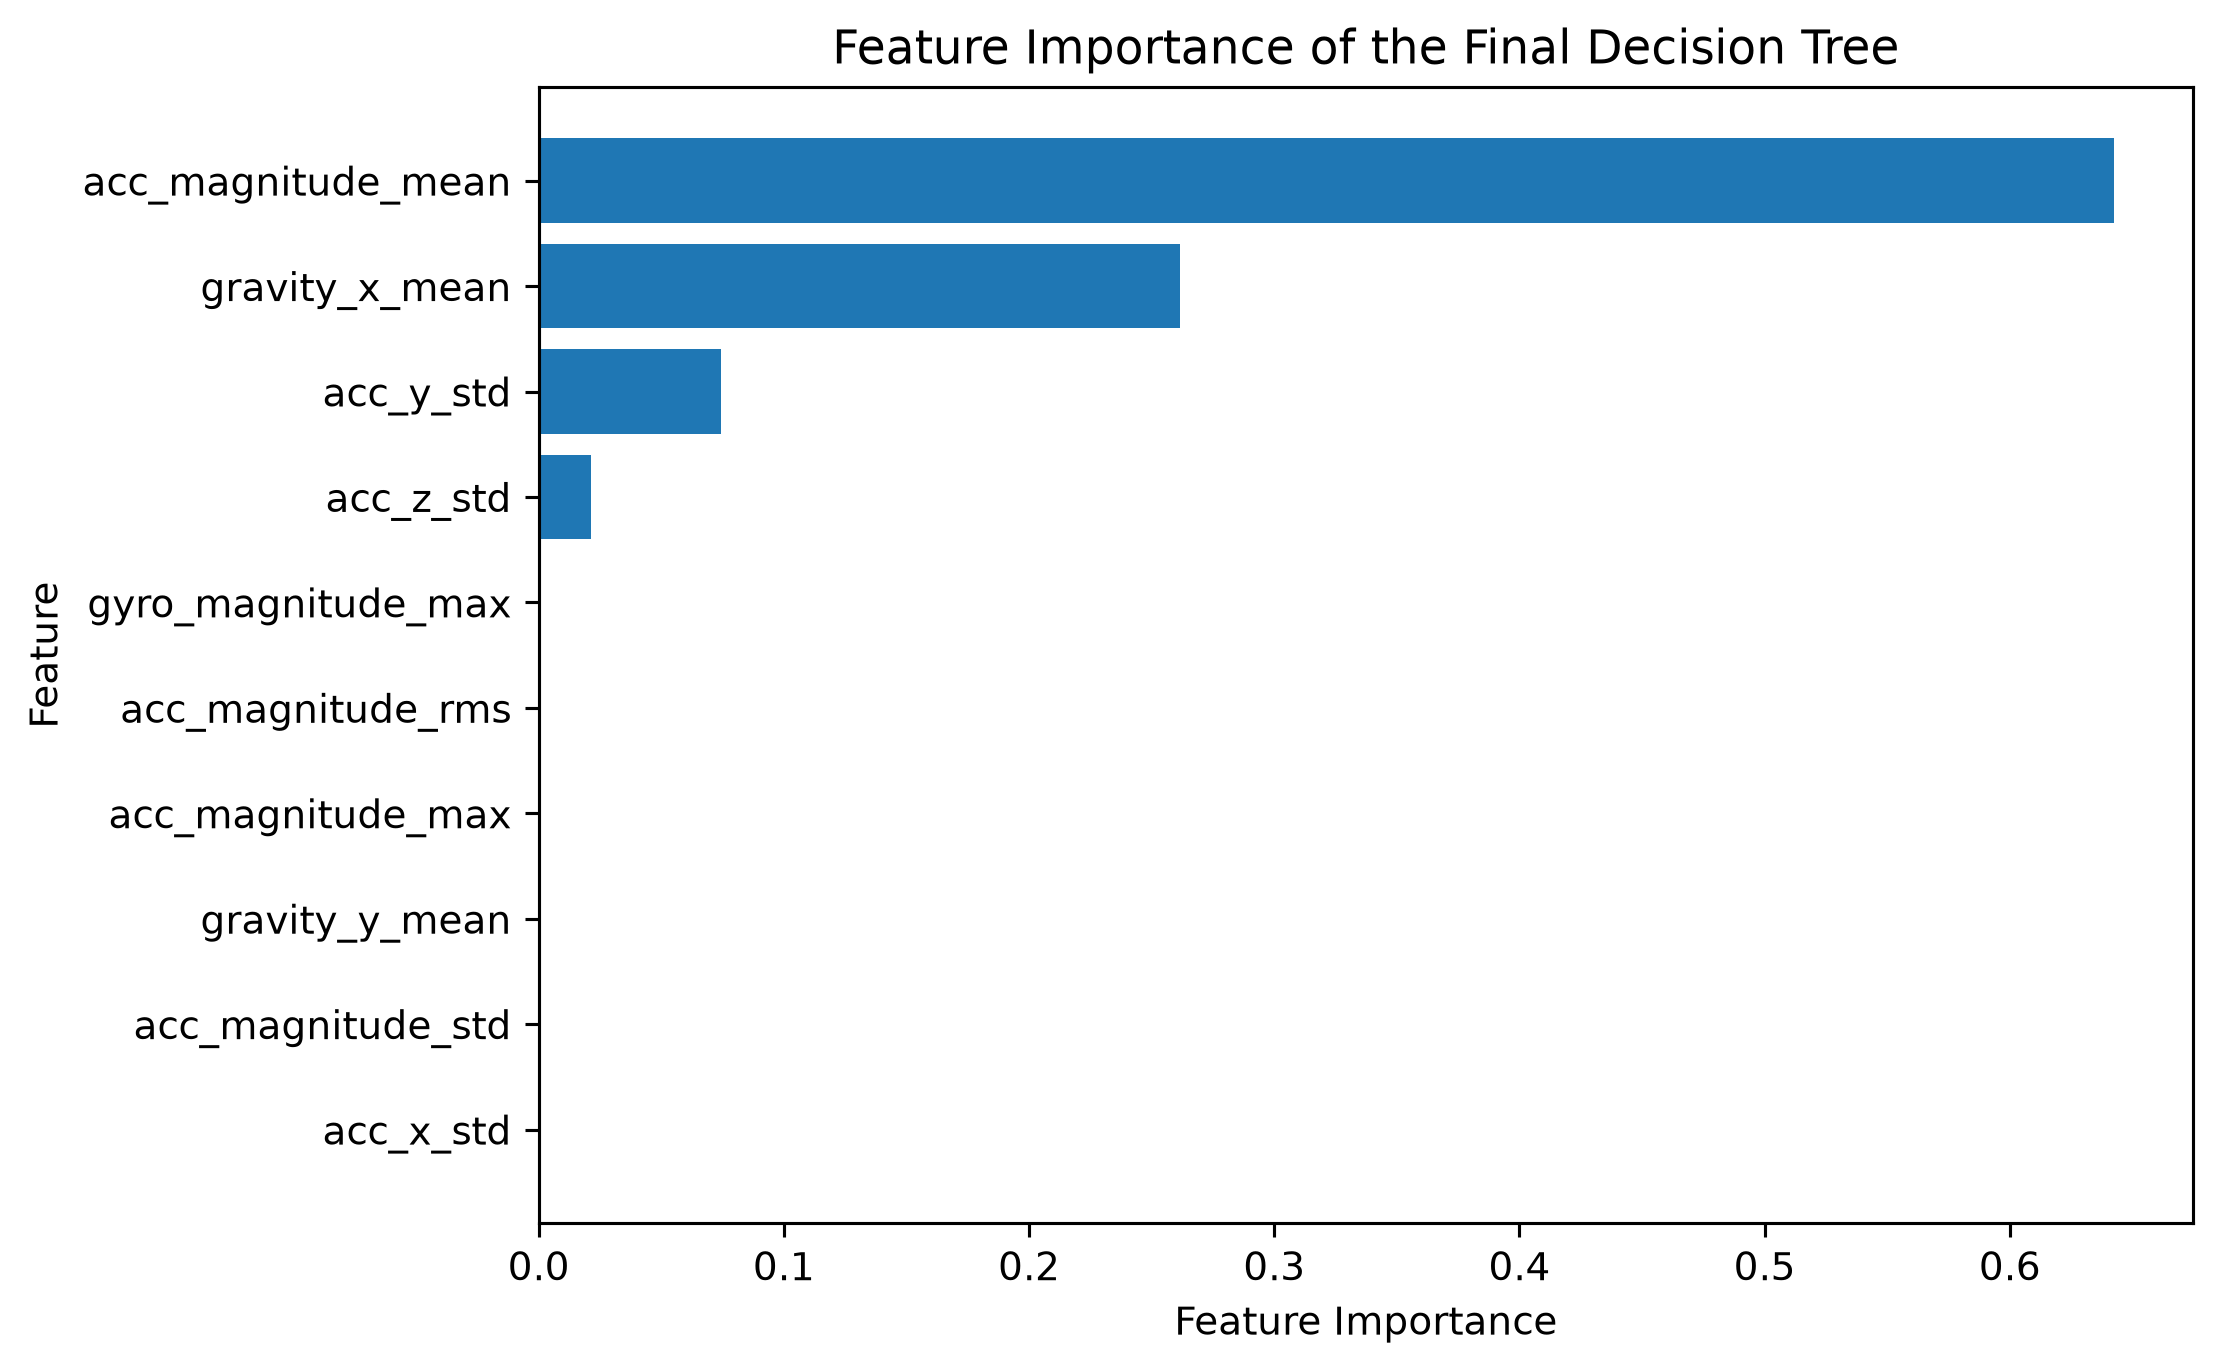

In [42]:
tree_model = final_model.named_steps["decision_tree"]

feature_importance_df = pd.DataFrame({
    "feature": final_selected_features,
    "importance": tree_model.feature_importances_
})

feature_importance_df = (
    feature_importance_df
    .sort_values("importance")
)

plt.figure(figsize=(8, 5))

plt.barh(
    feature_importance_df["feature"],
    feature_importance_df["importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Feature Importance of the Final Decision Tree")

plt.tight_layout()
plt.show()

*Note: This plot shows feature importance in the final fitted Decision Tree, whereas the feature-selection stability plot in Section 6.1 shows how consistently features were selected across LOSO folds.*

### 7.2 Load external dataset 

In [43]:
external_data_folder = project_folder / "DeploymentData"

external_acc_path = (external_data_folder / "Accelerometer.csv")

external_gyro_path = (external_data_folder / "Gyroscope.csv")

external_gravity_path = (external_data_folder / "Gravity.csv")

required_external_files = [external_acc_path, external_gyro_path, external_gravity_path]

for file_path in required_external_files:
    if not file_path.is_file():
        raise FileNotFoundError(
            f"External sensor file not found: {file_path}"
        )

print("External data folder:", external_data_folder)
print("All external files found.")

required_external_files = [external_acc_path, external_gyro_path, external_gravity_path]


external_acc = pd.read_csv(external_acc_path)
external_gyro = pd.read_csv(external_gyro_path)
external_gravity = pd.read_csv(
    external_gravity_path
)

# Verify that sensor timestamps align.
if not (
    external_acc["time"].equals(
        external_gyro["time"]
    )
    and external_acc["time"].equals(
        external_gravity["time"]
    )
):
    raise ValueError(
        "External sensor timestamps do not match."
    )

external_df = pd.DataFrame({
    "time": external_acc["time"],
    "seconds_elapsed":
        external_acc["seconds_elapsed"],

    "acc_x": external_acc["x"],
    "acc_y": external_acc["y"],
    "acc_z": external_acc["z"],

    "gyro_x": external_gyro["x"],
    "gyro_y": external_gyro["y"],
    "gyro_z": external_gyro["z"],

    "gravity_x": external_gravity["x"],
    "gravity_y": external_gravity["y"],
    "gravity_z": external_gravity["z"]
})

external_df["recording_id"] = (
    "external_recording"
)

print(
    "External measurements:",
    len(external_df)
)

print(
    "External duration:",
    round(
        external_df["seconds_elapsed"].max()
        - external_df["seconds_elapsed"].min(),
        2
    ),
    "seconds"
)

display(external_df.head())

External data folder: /Users/kathrain/Documents/University/Master/Y1/Q1/Data/Pavement-smoothness-detection-model/DeploymentData
All external files found.
External measurements: 101926
External duration: 1024.53 seconds


,time,seconds_elapsed,acc_x,acc_y,acc_z,gyro_x,gyro_y,gyro_z,gravity_x,gravity_y,gravity_z,recording_id
0,1724854953146595800,0.053596,-1.711618,-1.076428,1.773704,0.294301,1.315095,-1.706805,1.979021,-4.015740,-8.725118,external_recording
1,1724854953156648000,0.063648,-1.178875,-0.820191,1.043526,0.233846,1.511946,-1.691947,2.171570,-4.003677,-8.684771,external_recording
2,1724854953166699800,0.073700,-0.208286,0.433552,0.543858,0.181056,1.584875,-1.587968,2.373392,-3.984003,-8.640898,external_recording
3,1724854953176751900,0.083752,-0.475290,0.328924,0.340438,0.150255,1.529373,-1.451684,2.569020,-3.960479,-8.595646,external_recording
4,1724854953186803700,0.093804,-0.789170,-0.190948,0.309068,0.109078,1.511204,-1.296045,2.754361,-3.935159,-8.549760,external_recording


### 7.3 Apply preprocessing and windowing

In [44]:
# Apply the same boundary trimming used
# for the training recordings.
external_start = (
    external_df["seconds_elapsed"].min()
)

external_end = (
    external_df["seconds_elapsed"].max()
)

external_trimmed = external_df.loc[
    (
        external_df["seconds_elapsed"]
        >= external_start + trim_start
    )
    &
    (
        external_df["seconds_elapsed"]
        <= external_end - trim_end
    )
].copy()

# Create the same non-overlapping
# 2-second windows.
first_external_time = (
    external_trimmed["seconds_elapsed"].iloc[0]
)

external_trimmed["window_id"] = (
    (
        external_trimmed["seconds_elapsed"]
        - first_external_time
    )
    // window_duration
).astype(int)

# Check window sizes.
external_window_sizes = (
    external_trimmed
    .groupby(
        ["recording_id", "window_id"]
    )
    .size()
    .reset_index(name="n_samples")
)

# Use the same minimum of 180 samples.
external_valid_windows = (
    external_window_sizes.loc[
        external_window_sizes["n_samples"]
        >= min_samples,
        ["recording_id", "window_id"]
    ]
)

external_windowed = external_trimmed.merge(
    external_valid_windows,
    on=["recording_id", "window_id"],
    how="inner"
)

print(
    "External windows retained:",
    len(external_valid_windows)
)

External windows retained: 507


### 7.4 Extract exactly the same 26 features

In [45]:
# Magnitude features
external_windowed["acc_magnitude"] = np.sqrt(
    external_windowed["acc_x"]**2
    + external_windowed["acc_y"]**2
    + external_windowed["acc_z"]**2
)

external_windowed["gyro_magnitude"] = np.sqrt(
    external_windowed["gyro_x"]**2
    + external_windowed["gyro_y"]**2
    + external_windowed["gyro_z"]**2
)

# Mean and standard deviation
external_features = (
    external_windowed
    .groupby(
        ["recording_id", "window_id"]
    )[sensor_columns]
    .agg(["mean", "std"])
)

external_features.columns = [
    f"{sensor}_{statistic}"
    for sensor, statistic
    in external_features.columns
]

external_features = (
    external_features.reset_index()
)

# Additional magnitude features
external_magnitude_features = (
    external_windowed
    .groupby(
        ["recording_id", "window_id"]
    )
    .agg(
        acc_magnitude_max=(
            "acc_magnitude",
            "max"
        ),
        acc_magnitude_rms=(
            "acc_magnitude",
            lambda x: np.sqrt(
                np.mean(x**2)
            )
        ),
        gyro_magnitude_max=(
            "gyro_magnitude",
            "max"
        ),
        gyro_magnitude_rms=(
            "gyro_magnitude",
            lambda x: np.sqrt(
                np.mean(x**2)
            )
        )
    )
    .reset_index()
)

# Save each window's time range
external_window_info = (
    external_windowed
    .groupby(
        ["recording_id", "window_id"]
    )
    .agg(
        window_start=(
            "seconds_elapsed",
            "min"
        ),
        window_end=(
            "seconds_elapsed",
            "max"
        )
    )
    .reset_index()
)

external_features = (
    external_features
    .merge(
        external_magnitude_features,
        on=[
            "recording_id",
            "window_id"
        ]
    )
    .merge(
        external_window_info,
        on=[
            "recording_id",
            "window_id"
        ]
    )
)

# Put external features in exactly
# the same order as the training data.
X_external = (
    external_features[
        feature_columns
    ].copy()
)

assert list(X_external.columns) == list(X.columns)
assert np.isfinite(
    X_external.to_numpy()
).all()

print(
    "External feature matrix:",
    X_external.shape
)

External feature matrix: (507, 26)


### 7.5 Predict smooth and bumpy windows

In [46]:
external_predictions = (
    external_features[
        [
            "window_id",
            "window_start",
            "window_end"
        ]
    ].copy()
)

external_predictions["prediction"] = (
    final_model.predict(X_external)
)

prediction_mapping = {
    0: "smooth",
    1: "bumpy"
}

external_predictions[
    "predicted_condition"
] = (
    external_predictions["prediction"]
    .map(prediction_mapping)
)

print("Predicted external windows:")

display(
    external_predictions.head(10)
)

print("\nPrediction counts:")

display(
    external_predictions[
        "predicted_condition"
    ]
    .value_counts()
    .rename_axis("condition")
    .to_frame("windows")
)

Predicted external windows:


,window_id,window_start,window_end,prediction,predicted_condition
0,0,4.054251,6.044525,1,bumpy
1,1,6.054577,8.044848,1,bumpy
2,2,8.054900,10.045170,1,bumpy
3,3,10.055222,12.045477,1,bumpy
4,4,12.055529,14.045783,1,bumpy
5,5,14.055835,16.046073,1,bumpy
6,6,16.056125,18.046364,1,bumpy
7,7,18.056416,20.046640,1,bumpy
8,8,20.056692,22.046917,1,bumpy
9,9,22.056969,24.047191,1,bumpy



Prediction counts:


,windows
condition,
bumpy,476
smooth,31


### 7.6 Visualize predicted road sections

Consecutive windows with the same predicted condition are combined into continuous sections and displayed along the external recording timeline.

In [47]:
external_predictions["segment_id"] = (
    external_predictions[
        "predicted_condition"
    ]
    .ne(
        external_predictions[
            "predicted_condition"
        ].shift()
    )
    .cumsum()
)

external_segments = (
    external_predictions
    .groupby("segment_id")
    .agg(
        predicted_condition=(
            "predicted_condition",
            "first"
        ),
        start_time=(
            "window_start",
            "min"
        ),
        end_time=(
            "window_end",
            "max"
        ),
        windows=(
            "window_id",
            "count"
        )
    )
    .reset_index(drop=True)
)

external_segments["duration_seconds"] = (
    external_segments["end_time"]
    - external_segments["start_time"]
)

display(
    external_segments.round(2)
)

,predicted_condition,start_time,end_time,windows,duration_seconds
0,bumpy,4.05,144.05,70,140.00
1,smooth,144.06,150.05,3,5.99
2,bumpy,150.06,180.04,15,29.98
3,smooth,180.05,182.04,1,1.99
4,bumpy,182.05,400.04,109,217.99
5,smooth,400.05,402.04,1,1.99
6,bumpy,402.05,560.05,79,157.99
7,smooth,560.06,562.05,1,1.99
8,bumpy,562.06,662.04,50,99.99
9,smooth,662.05,664.05,1,1.99


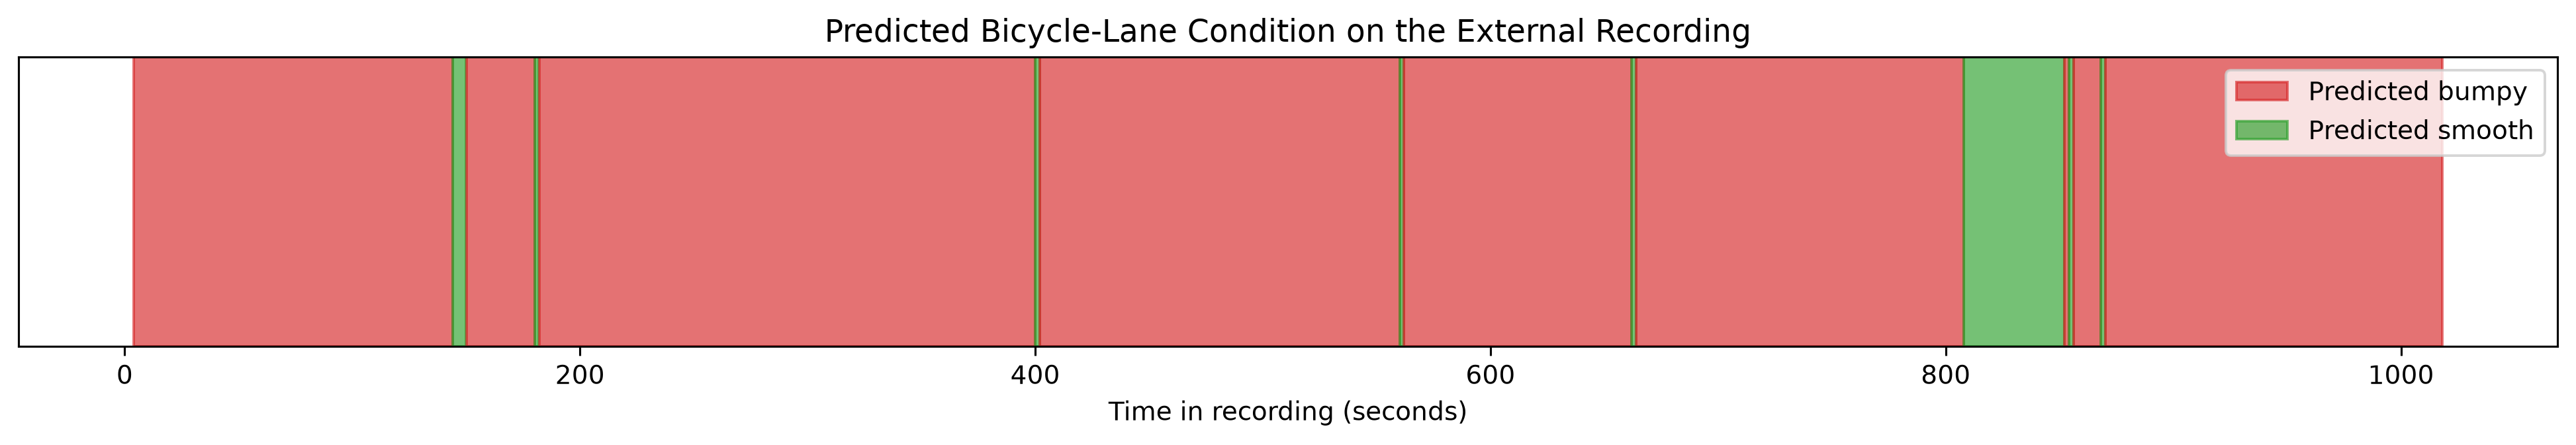

In [48]:
fig, ax = plt.subplots(
    figsize=(14, 2.5)
)

smooth_label_added = False
bumpy_label_added = False

for segment in external_segments.itertuples():

    if segment.predicted_condition == "smooth":
        color = "tab:green"

        label = (
            None
            if smooth_label_added
            else "Predicted smooth"
        )

        smooth_label_added = True

    else:
        color = "tab:red"

        label = (
            None
            if bumpy_label_added
            else "Predicted bumpy"
        )

        bumpy_label_added = True

    ax.axvspan(
        segment.start_time,
        segment.end_time,
        color=color,
        alpha=0.65,
        label=label
    )

ax.set_title(
    "Predicted Bicycle-Lane Condition "
    "on the External Recording"
)

ax.set_xlabel("Time in recording (seconds)")
ax.set_yticks([])

ax.legend(
    loc="upper right"
)

plt.tight_layout()
plt.show()

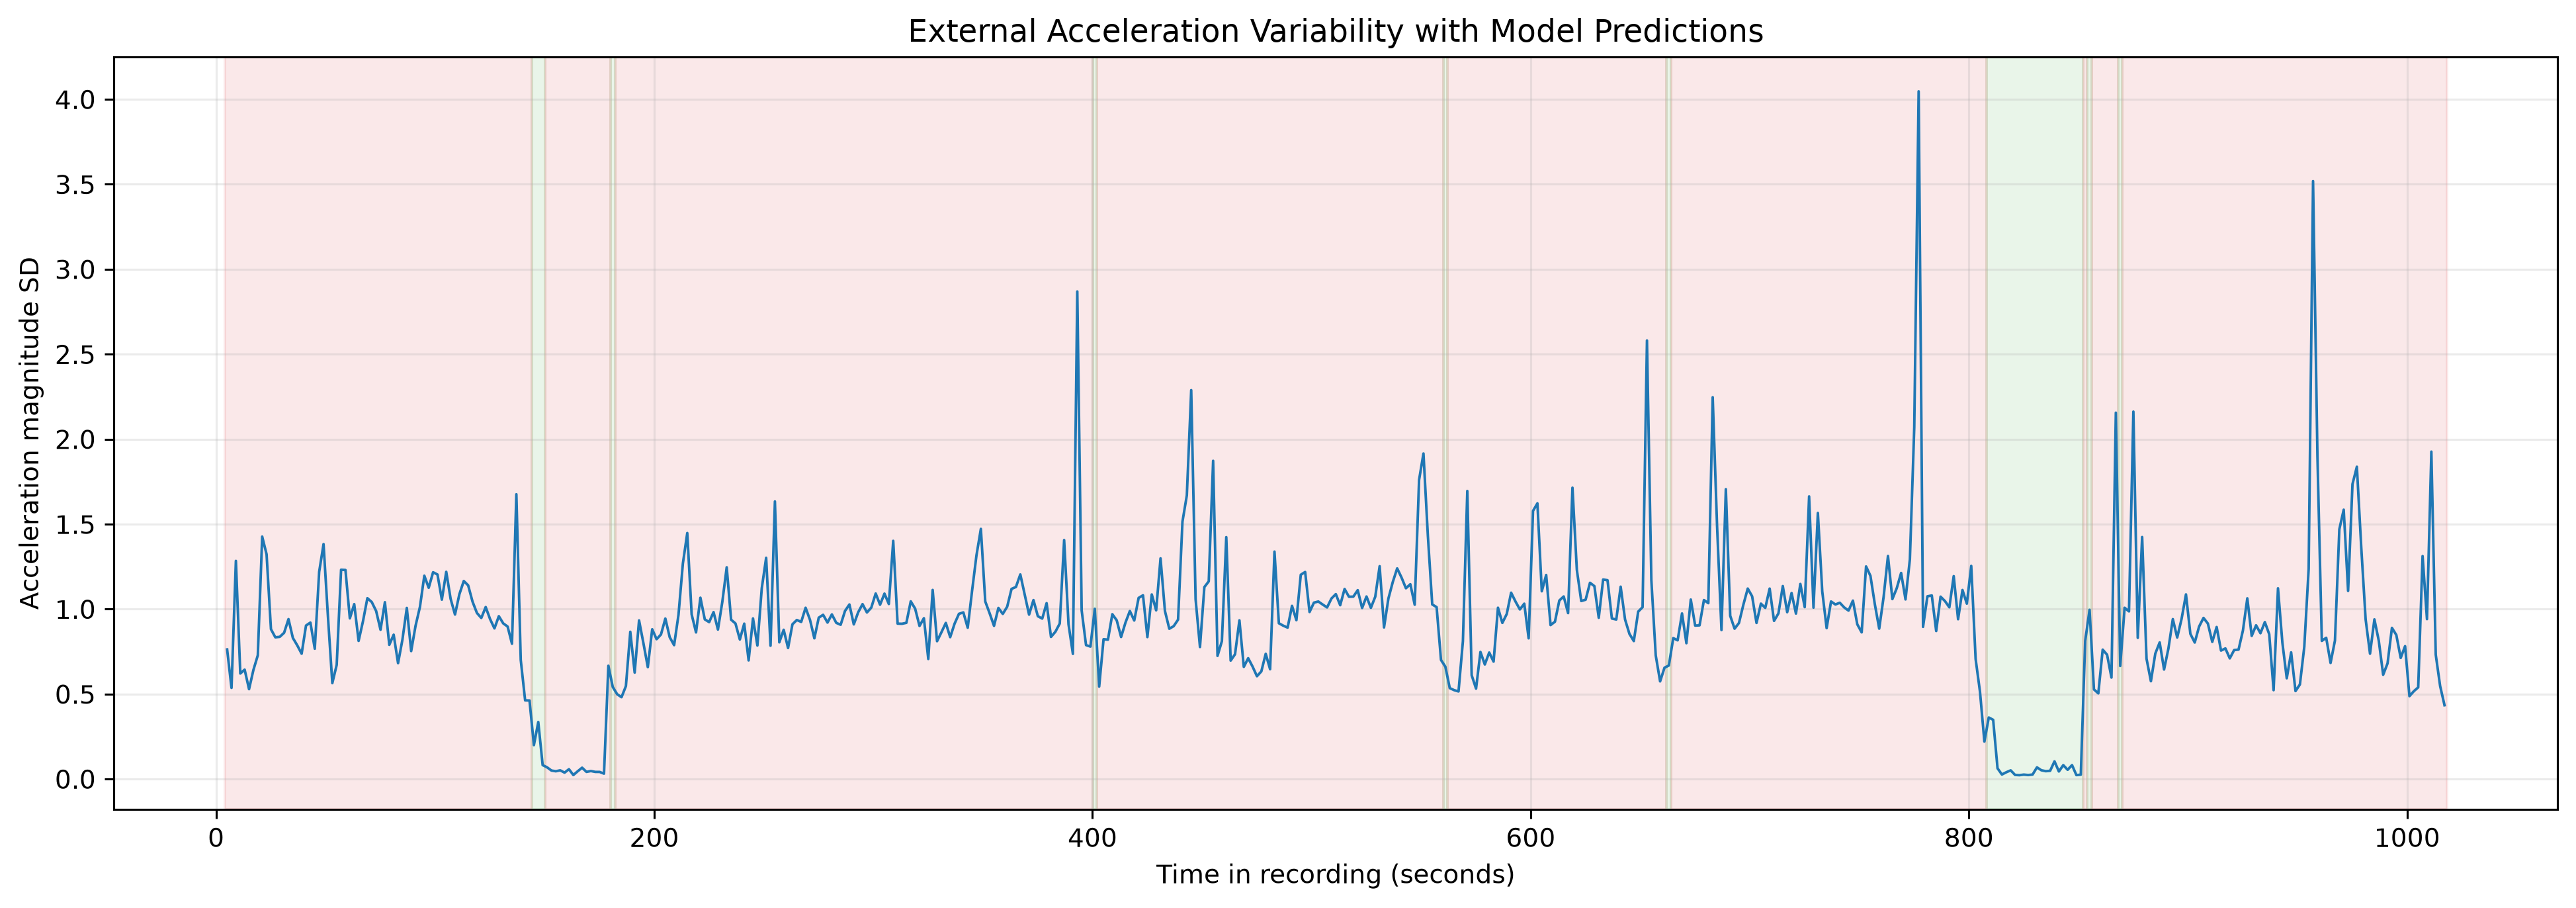

In [49]:
deployment_plot = external_predictions.copy()

deployment_plot["acc_magnitude_std"] = (
    X_external["acc_magnitude_std"].to_numpy()
)

deployment_plot["window_mid"] = (
    (
        deployment_plot["window_start"]
        + deployment_plot["window_end"]
    ) / 2
)

fig, ax = plt.subplots(
    figsize=(14, 5)
)

for segment in external_segments.itertuples():

    if segment.predicted_condition == "smooth":
        shade = "tab:green"
    else:
        shade = "tab:red"

    ax.axvspan(
        segment.start_time,
        segment.end_time,
        alpha=0.10,
        color=shade
    )

ax.plot(
    deployment_plot["window_mid"],
    deployment_plot["acc_magnitude_std"],
    linewidth=1
)

ax.set_title(
    "External Acceleration Variability "
    "with Model Predictions"
)

ax.set_xlabel(
    "Time in recording (seconds)"
)

ax.set_ylabel(
    "Acceleration magnitude SD"
)

ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

### 7.7 Deployment Diagnostics

Because the external predictions are strongly dominated by the bumpy class, the main Decision Tree rules and key feature distributions are inspected before interpreting the deployment result.

In [50]:
tree_model = final_model.named_steps[
    "decision_tree"
]

root_feature_index = (
    tree_model.tree_.feature[0]
)

root_feature = (
    final_selected_features[
        root_feature_index
    ]
)

root_threshold = (
    tree_model.tree_.threshold[0]
)

external_above_root = (
    X_external[root_feature]
    > root_threshold
)

print(
    "Root feature:",
    root_feature
)

print(
    "Root threshold:",
    round(root_threshold, 3)
)

print(
    "External windows above root threshold:",
    external_above_root.sum()
)

print(
    "Percentage:",
    round(
        external_above_root.mean() * 100,
        1
    ),
    "%"
)

Root feature: acc_magnitude_mean
Root threshold: 1.459
External windows above root threshold: 401
Percentage: 79.1 %


In [51]:
used_features = (
    feature_importance_df.loc[
        feature_importance_df["importance"] > 0,
        "feature"
    ]
    .tolist()
)

deployment_feature_comparison = pd.DataFrame({
    "smooth_training_mean":
        X.loc[y == 0, used_features].mean(),

    "bumpy_training_mean":
        X.loc[y == 1, used_features].mean(),

    "external_mean":
        X_external[used_features].mean()
})

display(
    deployment_feature_comparison.round(3)
)

,smooth_training_mean,bumpy_training_mean,external_mean
acc_z_std,0.560,1.327,0.748
acc_y_std,0.915,2.129,0.874
gravity_x_mean,0.846,1.863,7.875
acc_magnitude_mean,1.191,2.448,1.688


### 7.8 Deployment Interpretation

The final Decision Tree classified most external windows as bumpy. However, the external dataset has no ground-truth labels, so these predictions cannot be verified directly.

Further inspection showed that 78.9% of external windows exceeded the Decision Tree's main acceleration-magnitude threshold and were therefore immediately directed toward the bumpy class. The model also relied on `gravity_x_mean`, which differed substantially between the training and external datasets, suggesting sensitivity to phone orientation and participant-specific sensor patterns.

Therefore, the deployment visualization should be interpreted as the model's estimated road condition rather than a confirmed description of the external route.